# Imports

In [6]:
from scripts import data_functions, model_free_analysis, simulation_functions, weight_model_fit

In [3]:
from importlib import reload

In [64]:
reload(data_functions)
reload(model_free_analysis)
reload(simulation_functions)
reload(weight_model_fit)

<module 'scripts.weight_model_fit' from '/mnt/c/Users/faust/Dropbox/Tubingen/joint_learning/model/scripts/weight_model_fit.py'>

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import itertools as it
import seaborn as sns
import pandas as pd

import pymc3 as pm
import arviz as az
import theano 
from theano import tensor as tt
tprint = theano.printing.Print

from pprint import pprint

import pickle

# Experiment
Description of data, getting data, wrangling it into usable format

- 7 'referents':
    - 4 beings
    - 3 transitive actions
- 7 words
    - One for each referent
- Hypotheses 
    - Hypothesis space is the space of languages
    - Each language consists of a lexical interpretation function and a grammar (word order)
    - Interpretation function attributes one meaning to each word. There's 7! many of them (5040)
    - Grammar is just one of 6 possible word orders
    - Total of 30240 possible languages
- Priors
    - Possibly prior preference for some word orders
    - No prior knowledge about which words refer to which referents
    - I think it's reasonable to assume that the participant thinks that the interpretation function is a bijection (i.e. no homonymy or synonymy)
- Information in each trial:
    - 4 scenes (each consisting of one agent, one patient, and one transitive action)
    - 1 utterance
    - 1 selected scene
    - Whether the utterance applies to the scene
- Model
    - Purely inferential model isn't enough, because the agent is also *acting* to get as much information as possible.
    - Some kind of utility optimization
    - The model has two components:
        - Updating the knowledge about the language after each observation:
            - If the utterance and selected scene are compatible, then some interpretation functions can be eliminated
            - If not, the fact that the utterance had to apply to one of the remaining three scenes still contains information.
        - Picking the next scene from the list of 4, given an utterance and current distribution over languages.
            - Two possible aims: choose to reduce uncertainty about language, or try to get it right.
- Modeling less-than-perfect rationality
    - Qualitatively, the main problem is that there's too much information to remember
    - In other words, it is likely participant only use part of the information that they have seen
    - At any given point, they might be testing specific hypotheses about the true language
    - But modeling this kind of discrete reasoning is practically impossible
        - This is fine as long as it appears as _noise_ in the data
    - Unfortunately, because each trial is correlated with previous ones, not modelling the early ones properly can ruin inference about the later ones.
        - Can this be helped without explicitly modelling inference process?

Get data!

Reproduce the data wrangling in R from the intial code

In [5]:
data = data_functions.get_data()

data

,subject,counter,controller,type,condition,response,rank_partic
11,1,4,Form,consent,consent,yes,0
12,1,4,Form,consent,_REACTION_TIME_,19310,0
13,1,4,Form,demo,age,31,0
14,1,4,Form,demo,language,English,0
16,1,4,Form,demo,daily_language,English,0
...,...,...,...,...,...,...,...
14674,386,472,Form,outro1,_REACTION_TIME_,94374,385
14675,386,472,Form,outro2,strategy,First trying to work out what words were in co...,385
14676,386,472,Form,outro2,comments,I thought for a long time into it that I was n...,385
14677,386,472,Form,outro2,notes,no,385


For each participant, the 'condition' column takes the following values (the values of these rows are recorded in 'response' and also explained here):

- klin, praz, yabe, teck, neep, blom, vode
    - Artificial words.
    - The values in 'response' are the _participants' descriptions_ of the meanings corresponding to each word.
- subject, verb, object
    - Values in 'response' are 'first', 'second', 'third'. 
    - Encodes word orders.
- _REACTION_TIME_
    - Rts for specific points in the experiment. 
    - Column 'type' records which reaction time we're talking about
- strategy, comments, notes: 
    - Free text feedback from participant
- consent, age, language, prolific, daily_language, second_language, later_language, gender: 
    - Various recorded info about participant.
- clickedImage
    - Encodes a list. 
    - Which image was clicked. 
    - Recorded in the 'condition' columns as: 'targetSit', 'controlSit1', 'controlSit2', or 'controlSit3'.
- targetSit, controlSit1, controlSit2, controlSit3
    - Each encodes a list of scenes, one for each of the 200 trials.
    - Example of value in 'response': TriangleGreetHeart
- rt
    - Encodes a list, one for each of the 200 trials.
    - Reaction times for each answer.
- nounMap
    - From meaning of nouns to corresponding words
    - E.g., "Circle Triangle Heart Square maps to Teck Neep Blom Vode"
- verbMap
    - From meaning of verbs to the corresponding words
    - E.g., "Punch Photo Greet maps to Blom Praz Klin"
- wordOrderBox
    - Value is e.g., 'vso' or 'vos' etc.
    
The essential data for the language is contained in the `nounMap`, `verbMap`, and `wordOrderBox` column. The essential data for the trials is contained in `clickedImage`, `targetSit`, `controlSit1`, `controlSit2`, `controlSit3`. Everything else we can leave out for the purposes of model-based analysis.

Example of data recorded for single participant:

In [6]:
data[data['subject']==383]

,subject,counter,controller,type,condition,response,rank_partic
14527,383,471,Form,consent,consent,yes,382
14528,383,471,Form,consent,_REACTION_TIME_,7444,382
14529,383,471,Form,demo,age,31,382
14530,383,471,Form,demo,language,English,382
14532,383,471,Form,demo,daily_language,English,382
14533,383,471,Form,demo,second_language,NaN,382
14534,383,471,Form,demo,later_language,NaN,382
14535,383,471,Form,demo,gender,female,382
14536,383,471,Form,demo,_REACTION_TIME_,31391,382
14537,383,471,Form,instr1,_REACTION_TIME_,12102,382


In [7]:
data['condition'].unique()

array(['consent', '_REACTION_TIME_', 'age', 'language', 'daily_language',
       'second_language', 'later_language', 'gender', 'clickedImage',
       'targetSit', 'controlSit1', 'controlSit2', 'controlSit3', 'rt',
       'nounMap', 'verbMap', 'wordOrderBox', 'teck', 'neep', 'blom',
       'vode', 'klin', 'praz', 'yabe', 'subject', 'verb', 'object',
       'strategy', 'comments', 'notes'], dtype=object)

There should be this many participants: (NOTE: two of the original participants are in fact Bob and Xiaochen)

> __**TODO**__ Delete Bob and Xiaochen's results

In [8]:
64*6

384

In [9]:
chosen = data[data['condition']=='clickedImage']
chosen.loc[:,'response'] = chosen.loc[:,'response'].str.split()

/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/pandas/core/indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


In [10]:
# All participants did 200 trials
(chosen['response'].map(len) == 200).all()

True

```
for string in data[data['condition'] == 'strategy']['response']:
    print(string, '\n')
```

Put data in workable form.

In [11]:
analysis_arrays = data_functions.get_analysis_arrays(data)

/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/pandas/core/indexing.py:1597: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value
/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/pandas/core/indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


In [12]:
word_order_partic = analysis_arrays['word_order_partic'] 
interpretation_fs_partic = analysis_arrays['interpretation_fs_partic'] 
scenes_trials = analysis_arrays['scenes_trials'] 
true_scenes_trials = analysis_arrays['true_scenes_trials'] 
signals = analysis_arrays['signals'] 
history_choices_indices = analysis_arrays['history_choices_indices']
orders = analysis_arrays['orders']

Plot a simple summary of the data:

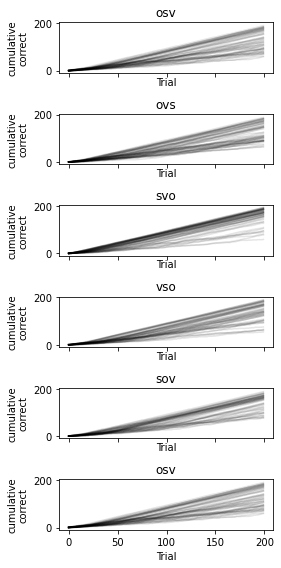

In [13]:
cumright = (history_choices_indices == 0).cumsum(0)

fig, axes = plt.subplots(
    6,
    1, 
    sharex=True, 
    sharey=True,
    figsize=(4,8)
)

for i, (ax, order) in enumerate(zip(axes.flatten(), word_order_partic)):
    ax.plot(
        cumright[:,np.argwhere(word_order_partic.values==order).flatten()], 
        alpha=0.1,
        color='black'
    )
    ax.set_title(order)

for ax in axes:
    ax.set_xlabel('Trial')
for ax in axes:
    ax.set_ylabel('cumulative\ncorrect')
    
plt.tight_layout()
plt.show()

# Model-free analysis
Use bambi to run logistic regression 

In [22]:
model, results, bmb_df = model_free_analysis.analyse(
    history_choices_indices, 
    word_order_partic
)

In [15]:
results

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

Sampling: [1|partic_sigma, Intercept, order_id, scaled_trial]


array([[<AxesSubplot:title={'center':'Intercept'}>,
        <AxesSubplot:title={'center':'scaled_trial'}>,
        <AxesSubplot:title={'center':'order_id\n1'}>,
        <AxesSubplot:title={'center':'order_id\n2'}>],
       [<AxesSubplot:title={'center':'order_id\n3'}>,
        <AxesSubplot:title={'center':'order_id\n4'}>,
        <AxesSubplot:title={'center':'order_id\n5'}>,
        <AxesSubplot:title={'center':'1|partic_sigma'}>]], dtype=object)

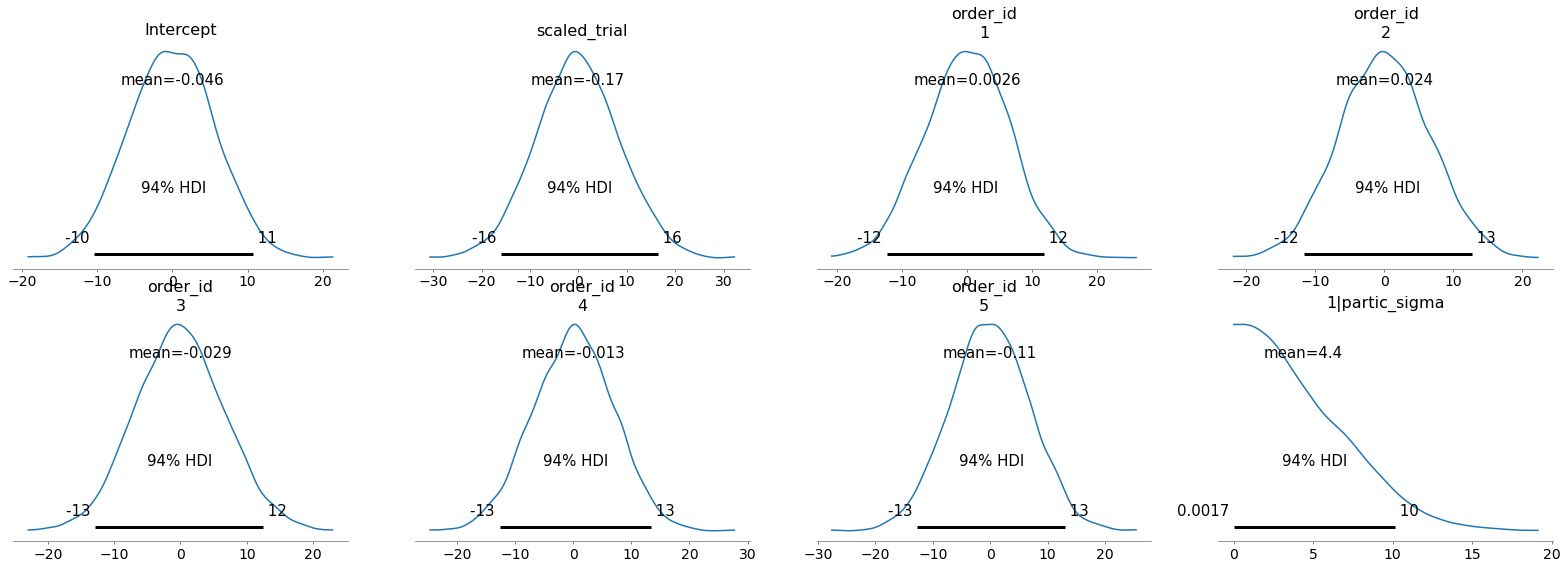

In [16]:
model.plot_priors()

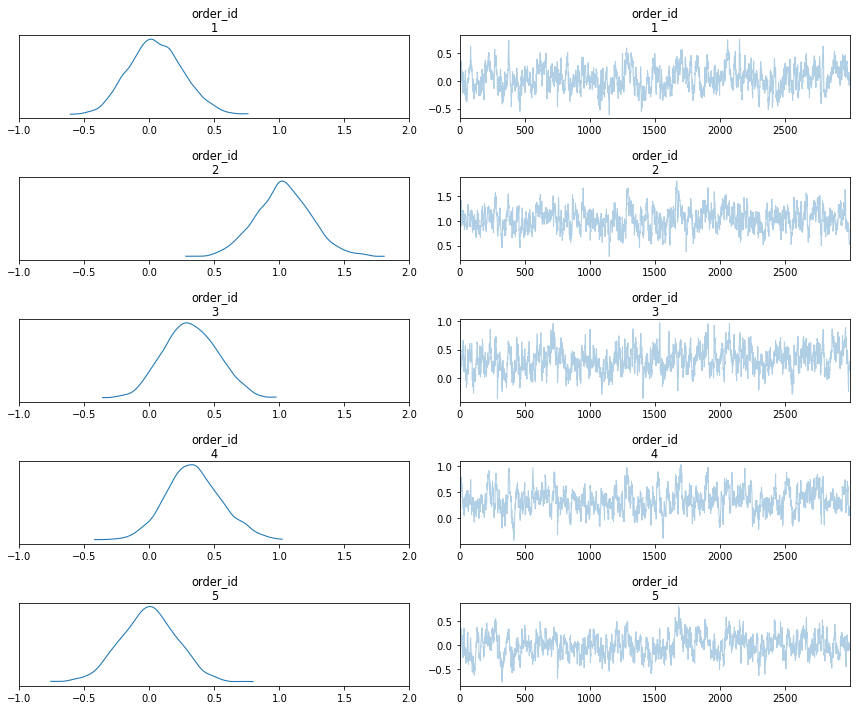

In [17]:
axes = az.plot_trace(
    results, 
    var_names=['order_id'], 
    compact=False
)
[ax.set_xlim(-1, 2) for ax in axes[:,0].flatten()]
plt.tight_layout()

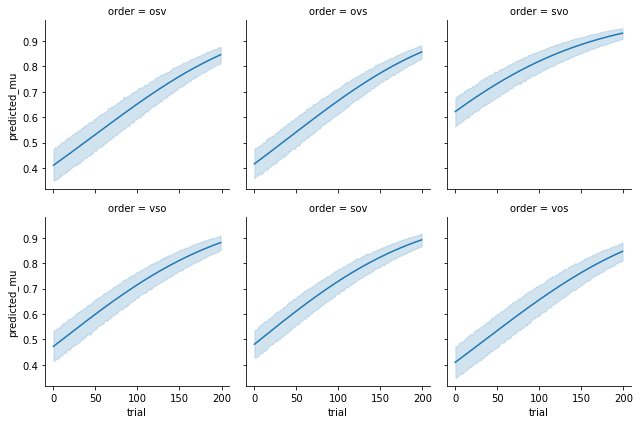

In [24]:
fg = sns.FacetGrid(
    bmb_df,
    col='order',
    col_wrap=3
)

fg.map(
    sns.lineplot,
    'trial',
    'predicted_mu'
)

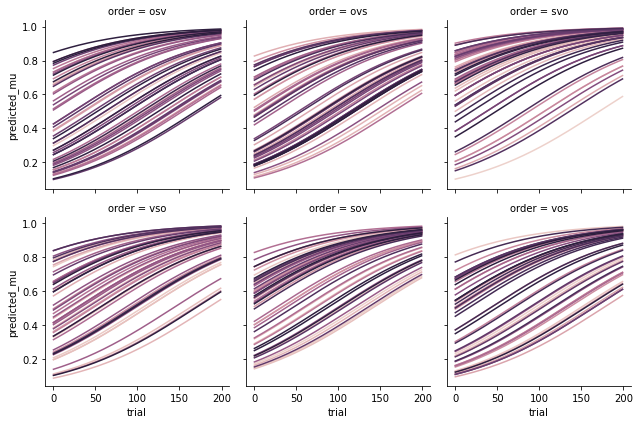

In [43]:
fg = sns.FacetGrid(
    bmb_df,
    col='order',
    col_wrap=3
)

fg.map(
    sns.lineplot,
    'trial',
    'predicted_mu',
    'partic',
    hue='blue'
)

In [44]:
# get the actual predicted intercepts
# from the reduced rank coding used by Bambi
predicted_intercepts = np.row_stack((
    results.posterior.Intercept.values.flatten(),
    (results.posterior.Intercept + results.posterior.order_id).values.reshape(-1,5).T
))

In almost all samples, the predicted intercept for the svo word order is higher than for all other word orders!

In [46]:
(predicted_intercepts[2] > predicted_intercepts).mean(1)

array([1.        , 1.        , 0.        , 0.999     , 0.99733333,
       1.        ])

# Basic Bayesian learning 
Simulate experiments w/ single participant!

Run single experiment:

In [27]:
index_true_language = (2,3)

scenes, languages, language_interpret, word_orders = simulation_functions.define_objects(
    full_output=True
)

word_order_prior, interpret_prior = simulation_functions.define_priors(
    word_orders, 
    language_interpret
)

trials = simulation_functions.generate_trials(
    languages[index_true_language], 
    10, 
    scenes, 
    4
)

history, _ = simulation_functions.run_experiment(
    trials, 
    interpret_prior, 
    word_order_prior, 
    negative_evidence=True
)

In [28]:
[h[index_true_language] for h in history]

[3.3068783068783064e-05,
 0.0023148148148148147,
 0.16666666666666666,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

Run multiple experiments:

1. Considering negative evidence

IntProgress(value=0)

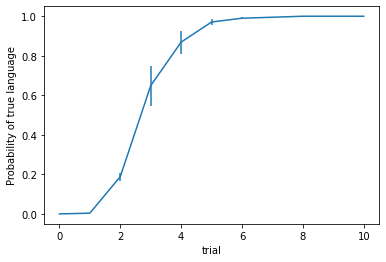

In [33]:
index_true_language = (2,3)

histories = simulation_functions.run_experiments(
    index_true_language, 
    interpret_prior, 
    word_order_prior, 
    n=100,
    negative_evidence=True
)

true_hists = [
    [h[index_true_language] for h in history]
    for history in histories
]

means, variances = np.mean(true_hists, 0), np.var(true_hists, 0)

fig, ax = plt.subplots()
ax.errorbar(np.arange(len(means)), means, variances)
ax.set_xlabel('trial')
ax.set_ylabel('Probability of true language')
plt.show()

2. Without considering negative evidence

IntProgress(value=0)

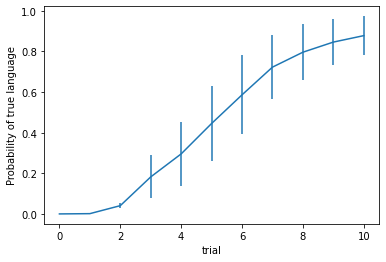

In [34]:
index_true_language = (2,3)

histories = simulation_functions.run_experiments(
    index_true_language, 
    interpret_prior, 
    word_order_prior, 
    n=100,
    negative_evidence=False
)

true_hists = [
    [h[index_true_language] for h in history]
    for history in histories
]

means, variances = np.mean(true_hists, 0), np.var(true_hists, 0)

fig, ax = plt.subplots()
ax.errorbar(np.arange(len(means)), means, variances)
ax.set_xlabel('trial')
ax.set_ylabel('Probability of true language')
plt.show()

# Description of association weights model (AWM)
High-level description of the generative model

This is a model of non-perfectly-Bayesian learning where at each timestep the associations between meaning-words, as well as word orders, are strenghtened (if they are compatible with the observation) or weakened (if they are not).

This is the model described in the PPT presentation

For word-meaning association array:

I only update the rows corresponding to the words used in the signal. For instance:
- If the signal is [0, 4, 2] I update rows 0, 4, and 2 

I only update the columns corresponding to the components of the scene. For instance:
- If the scene is [2, 5, 0] I update columns 2, 5, and 0.

Each row/col combination is updated by the probability of the word (row) being the one for the object (column), across all the word orders. For instance:
- Suppose the first word in the signal is 0 and the subject in the scene is object 2
- Then I want to increment the weight for element (0,2) in interpret_weights by the probability that word 0 is the one referring to object 2. 
    - This happens iff the word order is SOV or SVO (this behaves a lot like a likelihood)
- And this is repeated for each column / row

Snippet A in `update_weights` can be replaced by:

```python
# add prob that first word expresses the observed subject,
# i.e., the sum of the probabilities of the word orders that have 
# the subject in the first position
interpretation_weights[firstword, subj] += word_order_weights[[0,1]].sum()
# add prob that second word expresses the observed subject
interpretation_weights[secondword, subj] += word_order_weights[[2,4]].sum()
# add prob that third word expresses the observed subject
interpretation_weights[thirdword, subj] += word_order_weights[[3,5]].sum()

# add prob that first word expresses observed object
interpretation_weights[firstword, obj] += word_order_weights[[4,5]].sum()
# add prob that second word expresses observed object
interpretation_weights[secondword, obj] += word_order_weights[[1,3]].sum()
# add prob that third word expresses observed object
interpretation_weights[thirdword, obj] += word_order_weights[[0,2]].sum()

# add prob that first word expresses observed action
interpretation_weights[firstword, act] += word_order_weights[[2,3]].sum()
# add prob that second word expresses observed action
interpretation_weights[secondword, act] += word_order_weights[[0,5]].sum()
# add prob that third word expresses observed action
interpretation_weights[thirdword, act] += word_order_weights[[1,4]].sum()
```

and snippet B by:

```python
# prob of each word order combo
# following the word_orders array
# and the word_order_weights array
# Equivalent to:
# SVO
word_order_weights[0] += interpretation_weights[signal, [subj, act, obj]].prod()
# SOV
word_order_weights[1] += interpretation_weights[signal, [subj, obj, act]].prod()
# VSO
word_order_weights[2] += interpretation_weights[signal, [act, subj, obj]].prod()
# VOS
word_order_weights[3] += interpretation_weights[signal, [act, obj, subj]].prod()
# OSV
word_order_weights[4] += interpretation_weights[signal, [obj, subj, act]].prod()
# OV
word_order_weights[5] += interpretation_weights[signal, [obj, act, subj]].prod()
```

# AWM in numpy
Use simple numpy implementation to get a sense for the model

In [9]:
n_trials = 40
# (interpretation function, word_order)
index_true_language = (2,3)

In [10]:
scenes, languages, language_interpret, word_orders = simulation_functions.define_objects(
    full_output=True
)

word_order_prior, interpret_prior = simulation_functions.define_priors(
    word_orders, 
    language_interpret
)

trials = simulation_functions.generate_trials(
    languages[index_true_language], 
    n=n_trials, 
    scenes=scenes, 
    n_scenes_trial=4
)

true_scenes, indices_scenes_trials, signals = trials

history_states, history_choices = simulation_functions.run_experiment(
    trials, 
    interpret_prior, 
    word_order_prior, 
    negative_evidence=False
)

# go from the actual chosen scenes to their indices
history_choices_indices = np.argwhere(
    indices_scenes_trials == np.array(history_choices)[:,None]
)[:,1]

[0 6 3] [6 3 0] 



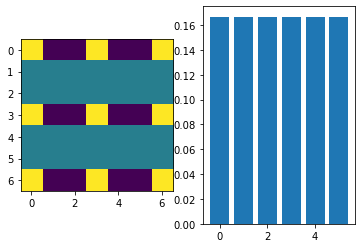

[3 4 2] [5 2 3] 



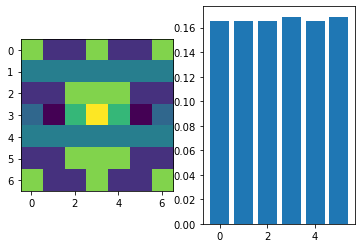

[1 5 2] [4 2 1] 



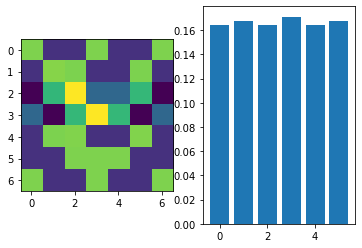

[2 5 0] [4 0 2] 



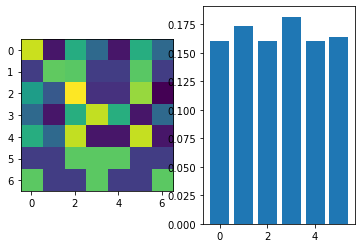

[3 5 0] [4 0 3] 



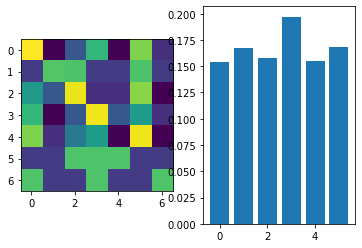

[0 5 3] [4 3 0] 

[1 6 3] [6 3 1] 

[0 4 2] [5 2 0] 

[2 6 3] [6 3 2] 

[3 5 2] [4 2 3] 

[2 5 3] [4 3 2] 

[1 5 3] [4 3 1] 

[3 5 1] [4 1 3] 

[1 4 3] [5 3 1] 

[0 5 3] [4 3 0] 

[2 4 1] [5 1 2] 

[1 6 3] [6 3 1] 

[0 5 3] [4 3 0] 

[3 5 0] [4 0 3] 

[2 4 0] [5 0 2] 

[3 5 1] [4 1 3] 

[2 6 3] [6 3 2] 

[1 4 3] [5 3 1] 

[1 4 0] [5 0 1] 

[2 6 1] [6 1 2] 

[0 4 1] [5 1 0] 

[1 4 3] [5 3 1] 

[2 4 1] [5 1 2] 

[2 5 1] [4 1 2] 

[1 6 3] [6 3 1] 

[0 4 2] [5 2 0] 

[3 4 1] [5 1 3] 

[1 6 3] [6 3 1] 

[1 6 0] [6 0 1] 

[1 6 2] [6 2 1] 

[1 5 3] [4 3 1] 

[0 4 2] [5 2 0] 



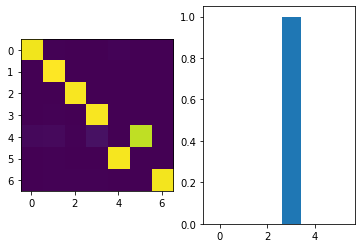

[3 5 1] [4 1 3] 



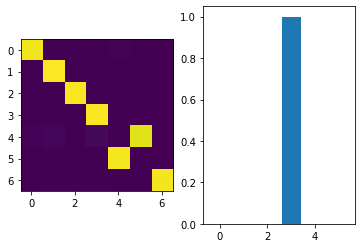

[1 4 2] [5 2 1] 



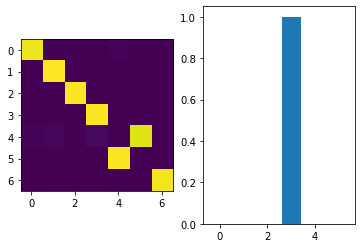

[0 6 1] [6 1 0] 



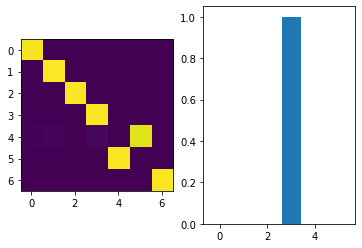

In [13]:
scenes, languages, language_interpret, word_orders = simulation_functions.define_objects(
        full_output=True)

# dims (word, meaning)
# probability that each word has each meaning
interpretation_weights = simulation_functions.normalize(
    np.ones((7,7)),
    axis=1
)

# dims (word order)
word_order_weights = simulation_functions.normalize(
    np.ones(6)
)

for i, (true_scene_index, signal) in enumerate(zip(true_scenes, signals)):
    
    true_scene = scenes[true_scene_index]
    
    print(true_scene, signal, '\n')
    
    interpretation_weights, word_order_weights = weight_model_fit.update_weights(
        interpretation_weights, 
        word_order_weights, 
        true_scene, 
        signal
    )
    
    # print(word_order_weights)
    # print(interpretation_weights)
    
    if (i < 5) or (i > len(true_scenes)-5):
        fig, (ax1, ax2) = plt.subplots(1,2)
        ax1.imshow(interpretation_weights)
        ax2.bar(np.arange(len(word_order_weights)), word_order_weights)
        plt.show()

# AWM in pymc3 - profiling / testing
TODO: This section is a bit outdated, rewrite

## Profiling single participant to speed up model

Profiling the model shows that 93% of the time is spent on the scan operation.

```python
model.profile(model.logpt).summary()
```

Since it's difficult to look inside the scan, it makes sense to just run the `update_weights_theano` function by itself:

In [ ]:
theano.config.compute_test_value = 'ignore'
scene = tt.vector('scene', 'int32')
signal = tt.vector('signal', 'int32')
interpretation_weights = tt.matrix('int weights', dtype='float32')
word_order_weights = tt.matrix('word order weights', dtype='float32')

output = weight_model_fit.update_weights_theano(
    scene, 
    signal, 
    interpretation_weights, 
    word_order_weights, 
    word_orders
)

f = theano.function(
    inputs = [
        scene,
        signal,
        interpretation_weights,
        word_order_weights
    ],
    outputs = output,
    profile=True
)

theano.config.compute_test_value = 'raise'

In [ ]:
f.profile.summary()

In [ ]:
profilemodel.profile(profilemodel.logpt).summary()

## Testing functions

This section needs rewriting!

In [9]:
def test_function(signal, word_orders, scene, int_weights, wordorder_weights, learning_weights):
    
    n_participants = signals.shape[1]
    
    scene_theano = theano.shared(scene)
    signal_theano = theano.shared(signal)
    interpretation_weights_original = theano.shared(int_weights)
    word_order_weights_original = theano.shared(wordorder_weights)
    word_orders_theano = theano.shared(word_orders)
    learning_weights_theano = theano.shared(learning_weights)
    
    results = update_weights_theano_multiple_participants(
        scene_theano, 
        signal_theano, 
        interpretation_weights_original, 
        word_order_weights_original, 
        word_orders_theano,
        learning_weights
    )
    
    f = theano.function(
        (),
        results
    )
    return f()

```
theano.config.compute_test_value = 'ignore'

orders.shape

i_trial = 30

signal = signals[i_trial]
scene = signals[i_trial]
# int_weights = interpretation_weights_f[i_trial]
int_weights = normalize(
    np.ones_like(interpretation_fs_partic), 
    axis=-1
)
# word_order_weights = word_order_weights_f[i_trial]
word_order_weights = normalize(
    np.ones((len(orders),6)),
    -1
)
learning_weights = np.ones(len(int_weights))

p1, r1 = test_function(
    signal, 
    orders, 
    scene,
    int_weights,
    word_order_weights,
    learning_weights
)
p2, r2 = test_function(
    signal[:30], 
    orders, 
    scene[:30],
    int_weights[:30],
    word_order_weights[:30],
    learning_weights[:30]
)

(p1[:30] == p2).all()

(int_weights[:30] == p2).all((1,2))
```

# AWM in pymc3 - Prior predictive and parameter recovery
Create simulated datasets by sampling from the prior, and try to recover the true parameters

## Sample prior data

This section can be used to either generate the data from the Bayesian agents, or to generate a set of independent variables to run prior predictive samples with the pymc3 model.

In [14]:
n_trials = 20
n_participants = 100

In [26]:
simulated_results, simulated_data = weight_model_fit.prior_predictive_sample(
    n_trials, 
    n_participants
)

In [32]:
# Define objects in namespace
# Also so it can be used below for parameter recovery!

ppc_word_order_prior = simulated_data['word_order_prior'][0]
ppc_chosen_scenes = simulated_data['chosen_scenes'][0]
ppc_p_wordorders = simulated_data['probs_orders'][0]
ppc_learning_weights = simulated_data['learning_weights'][0]
ppc_hyper_ms = simulated_data['hyper_ms'].flatten()

scenes_trials = simulated_results['scenes_trials']
true_scenes_trials = simulated_results['true_scenes_trials']
indices_true_language = simulated_results['indices_true_language']
signals = simulated_results['signals']

In [18]:
{
    k: value.shape
    for k, value 
    in simulated_results.items()
}

{'true_scenes': (20, 100),
 'indices_scenes_trials': (20, 100, 4),
 'signals': (20, 100, 3),
 'scenes_trials': (20, 100, 4, 3),
 'true_scenes_trials': (20, 100, 3),
 'indices_true_language': (100, 2)}

<BarContainer object of 6 artists>

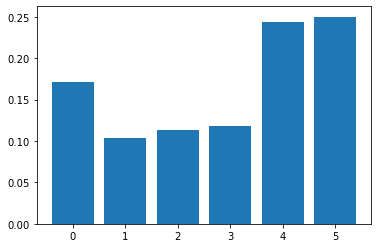

In [19]:
plt.bar(np.arange(len(ppc_hyper_ms)), ppc_hyper_ms)

Did not plot one participant who was always right
Did not plot one participant who was always right
Did not plot one participant who was always right
Did not plot one participant who was always right


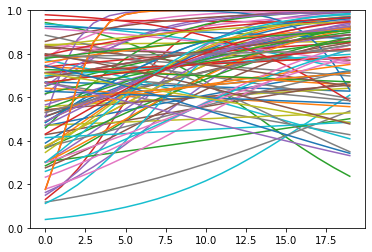

In [24]:
from sklearn.linear_model import LogisticRegression

xs, ys = np.indices(ppc_chosen_scenes.shape)
true_by_trial = (
    scenes_trials[xs, ys, ppc_chosen_scenes] 
    == true_scenes_trials
).all(-1)

# plot the participants' estimated probability
# of getting answers right
# by trial (it should increase)
xs = np.arange(len(ys)).reshape(-1,1)
for i, ys in enumerate(true_by_trial.T):
    try:
        clf = LogisticRegression().fit(
            xs, 
            ys
        )
        plt.plot(clf.predict_proba(xs).T[1], label=i)
    
    except ValueError:
        print('Did not plot one participant who was always right')

# plt.legend()
plt.ylim(0,1)
plt.show()

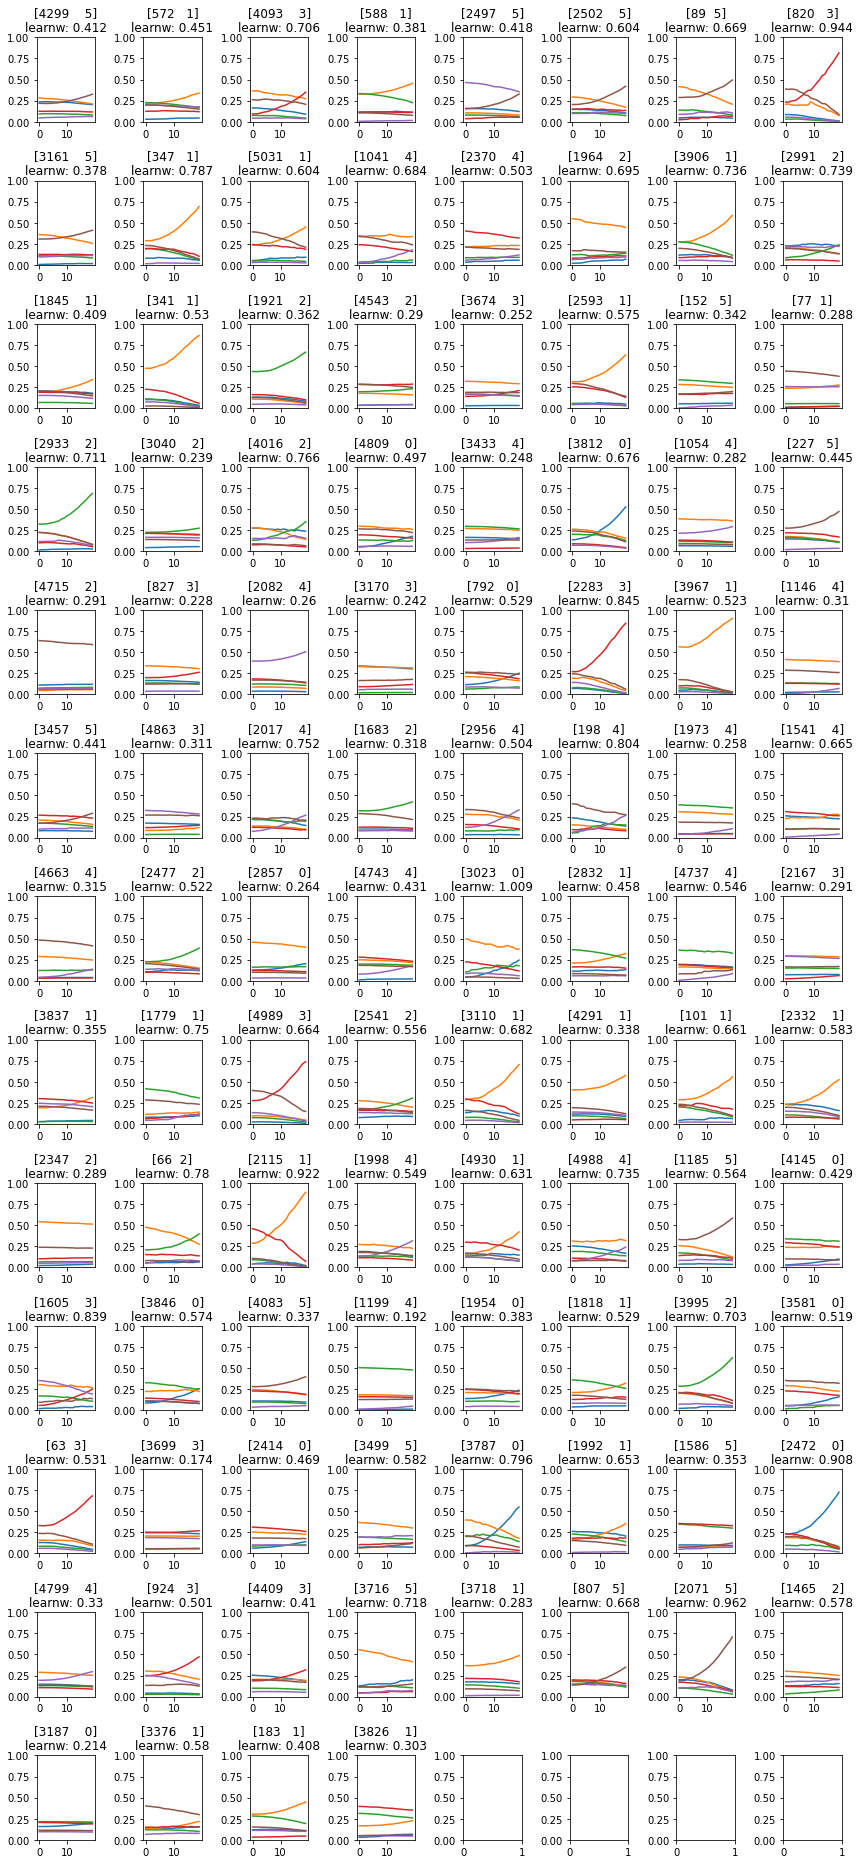

In [27]:
# Plot the probability of each word order by trial
# for each participant

n_partic = ppc_p_wordorders.shape[1]

n_rows, n_cols = np.ceil(n_partic / 8).astype(int), 8
fig, axes = plt.subplots(
    n_rows,
    n_cols, 
    figsize=(12,2*n_rows)
)
for i, j in enumerate(ppc_p_wordorders.swapaxes(0, 1)):
    ax = axes.flatten()[i]
    ax.set_title(
        str(indices_true_language[i]) 
        + f'\nlearnw: {round(ppc_learning_weights[i],3)}'
    )
    ax.plot(j)
    ax.set_ylim(0,1)
plt.tight_layout()
# plt.show()
plt.savefig('figures/prior_samples.png', dpi=300)

## Parameter recovery
NOTE: Uses the dataset simulated in the previous section!

### With variational inference

First produce the simulated data for one full experiment in the section right above `Prior predictive samples`

In [ ]:
scenes, languages, language_interpret, word_orders = simulation_functions.define_objects(
    full_output=True
)

In [33]:
ppc_model = weight_model_fit.factory_weight_model_multiple_participants(
    true_scenes_trials,
    signals,
    word_orders,
    ppc_chosen_scenes,
    scenes_trials
)

In [202]:
with ppc_model:
    ppc_fit = pm.fit(n=50000)

Finished [100%]: Average Loss = 10,794


In [205]:
with model:
    ppc_fit_samples = az.from_pymc3(
        ppc_fit.sample(1000)
    )

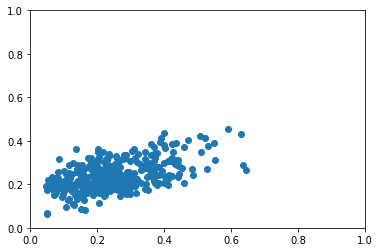

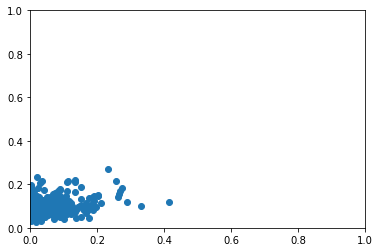

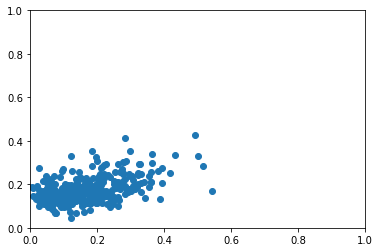

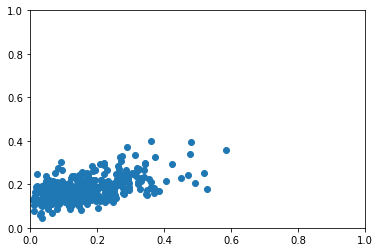

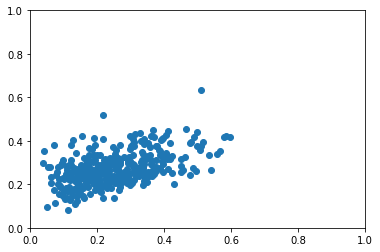

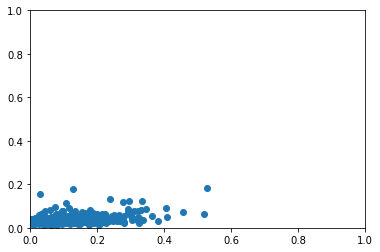

In [207]:
for i in range(6):
    plt.scatter(
        # true word order priors
        ppc_word_order_prior[:,i],
        # mean of estimated word order prior
        ppc_fit_samples.posterior.word_order_prior.values[0].mean(0)[:,i]
    )
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.show()

### With HMC

In [ ]:
scenes, languages, language_interpret, word_orders = simulation_functions.define_objects(
    full_output=True
)

In [34]:
ppc_model = weight_model_fit.factory_weight_model_multiple_participants(
    true_scenes_trials,
    signals,
    word_orders,
    ppc_chosen_scenes,
    scenes_trials
)

In [51]:
with ppc_model:
    ppc_samples = pm.sample(
        return_inferencedata=True
    )

WARNING (theano.tensor.opt): Optimization Warning: The Op erfcx does not provide a C implementation. As well as being potentially slow, this also disables loop fusion.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [learning_weights, learning_weights_sigma, learning_weights_mu, word_order_prior, hyper_gammas]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1765 seconds.
There were 8 divergences after tuning. Increase `target_accept` or reparameterize.
The estimated number of effective samples is smaller than 200 for some parameters.


In [55]:
with open('./ppc_samples.pickle', 'wb') as openfile:
    pickle.dump(ppc_samples, openfile)

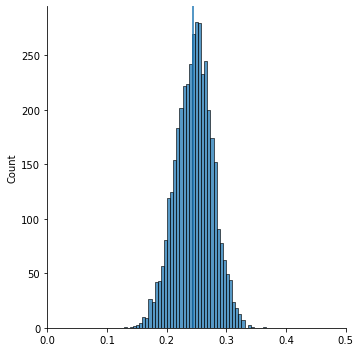

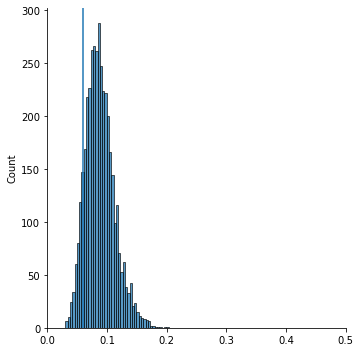

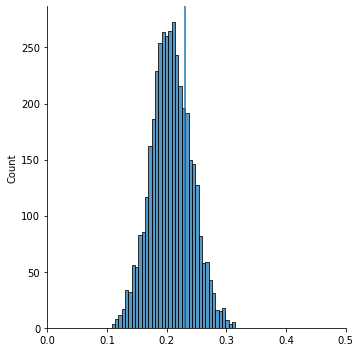

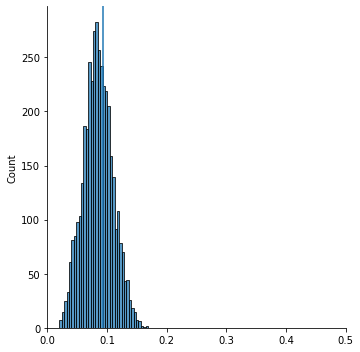

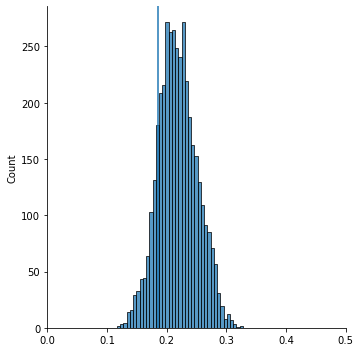

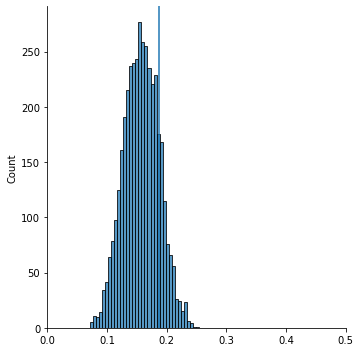

In [58]:
for true_value, samples in zip(
                simulated_data['hyper_ms'].flatten(), 
                ppc_samples.posterior.hyper_ms.values.reshape(-1,6).T
            ):
    sns.displot(samples)
    plt.axvline(true_value)
    plt.xlim(0, 0.5)
    plt.show()

/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/arviz/plots/backends/matplotlib/pairplot.py:232: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


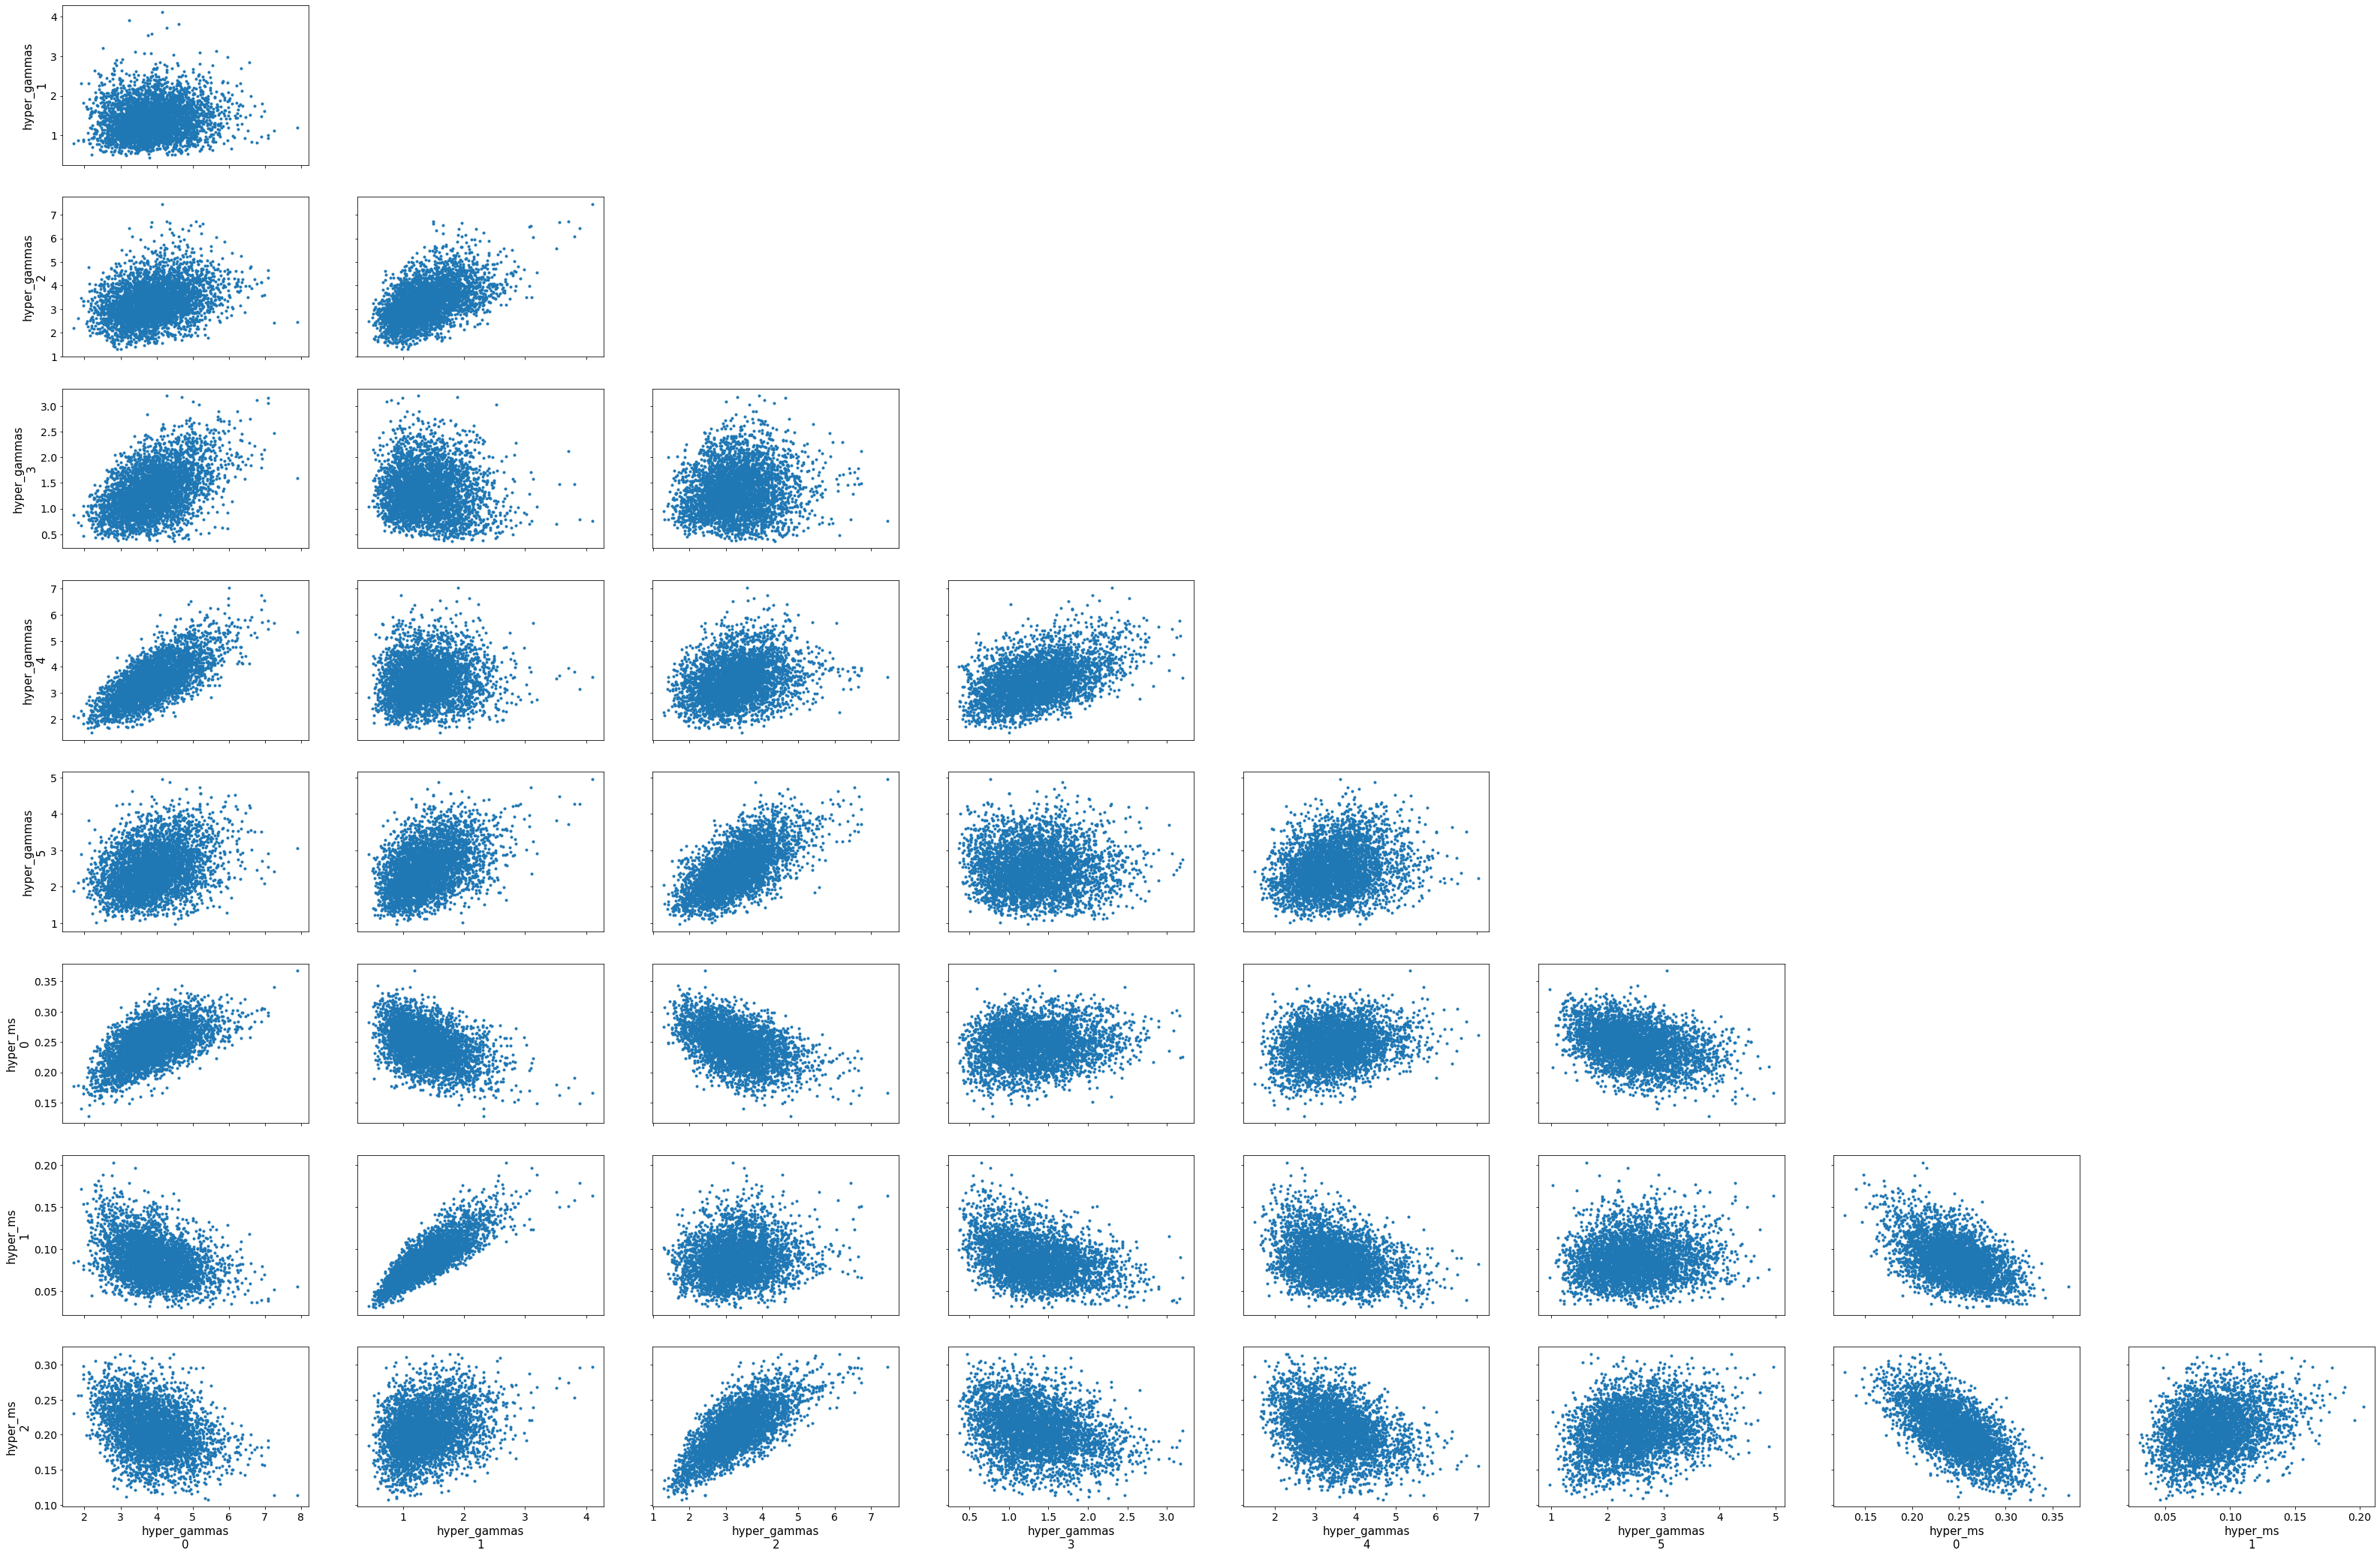

In [98]:
az.plot_pair(
    ppc_samples,
    var_names='hyper_(ms|gamma)',
    filter_vars='regex'
)
plt.show()

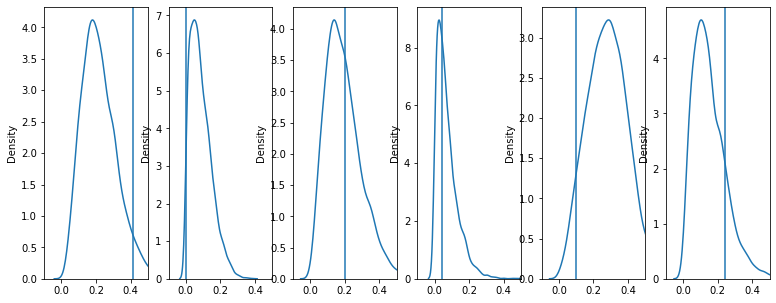

In [96]:
i_part = 4

fig, axes = plt.subplots(1,6, figsize=(13,5))
participant = ppc_samples.posterior.word_order_prior.values.reshape(-1,100,6)[:,i_part]
for i,row in enumerate(participant.T):
    sns.kdeplot(row,ax=axes[i])
    axes[i].axvline(ppc_word_order_prior[i_part,i])
    axes[i].set_xlim(-0.1,0.5)
plt.show()

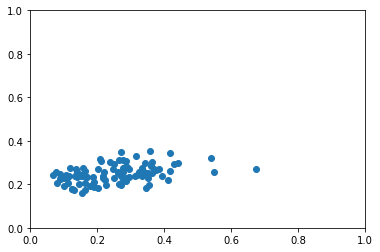

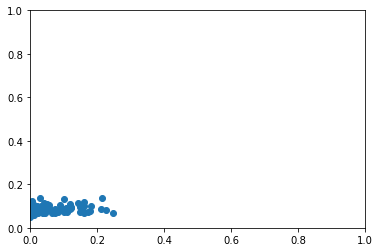

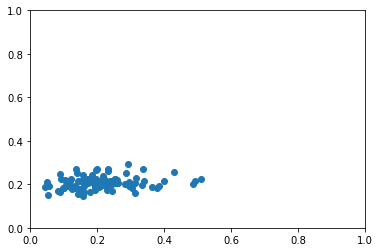

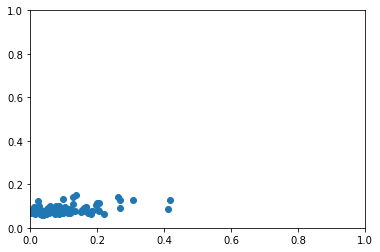

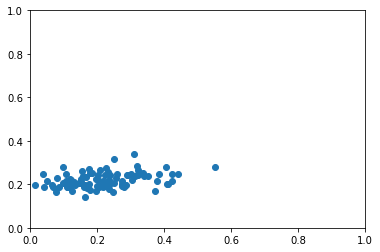

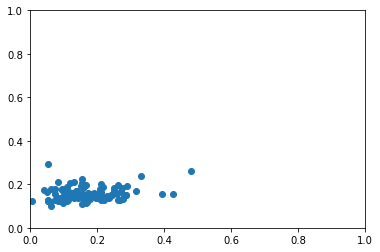

In [72]:
for i in range(6):
    plt.scatter(
        # true word order priors
        ppc_word_order_prior[:,i],
        # mean of estimated word order prior
        ppc_samples.posterior.word_order_prior.values.mean((0,1))[:,i]
    )
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.show()

# Fit pilot data with association weights model

## Without participants exclusion, full dataset

In [ ]:
data, analysis_arrays, model, trace = weight_model_fit.get_and_fit_data(
    participant_exclusion=False, 
    method='variational'
)

/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/arviz/plots/plot_utils.py:271: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (386) in plot_posterior, generating only 40 plots
  warnings.warn(


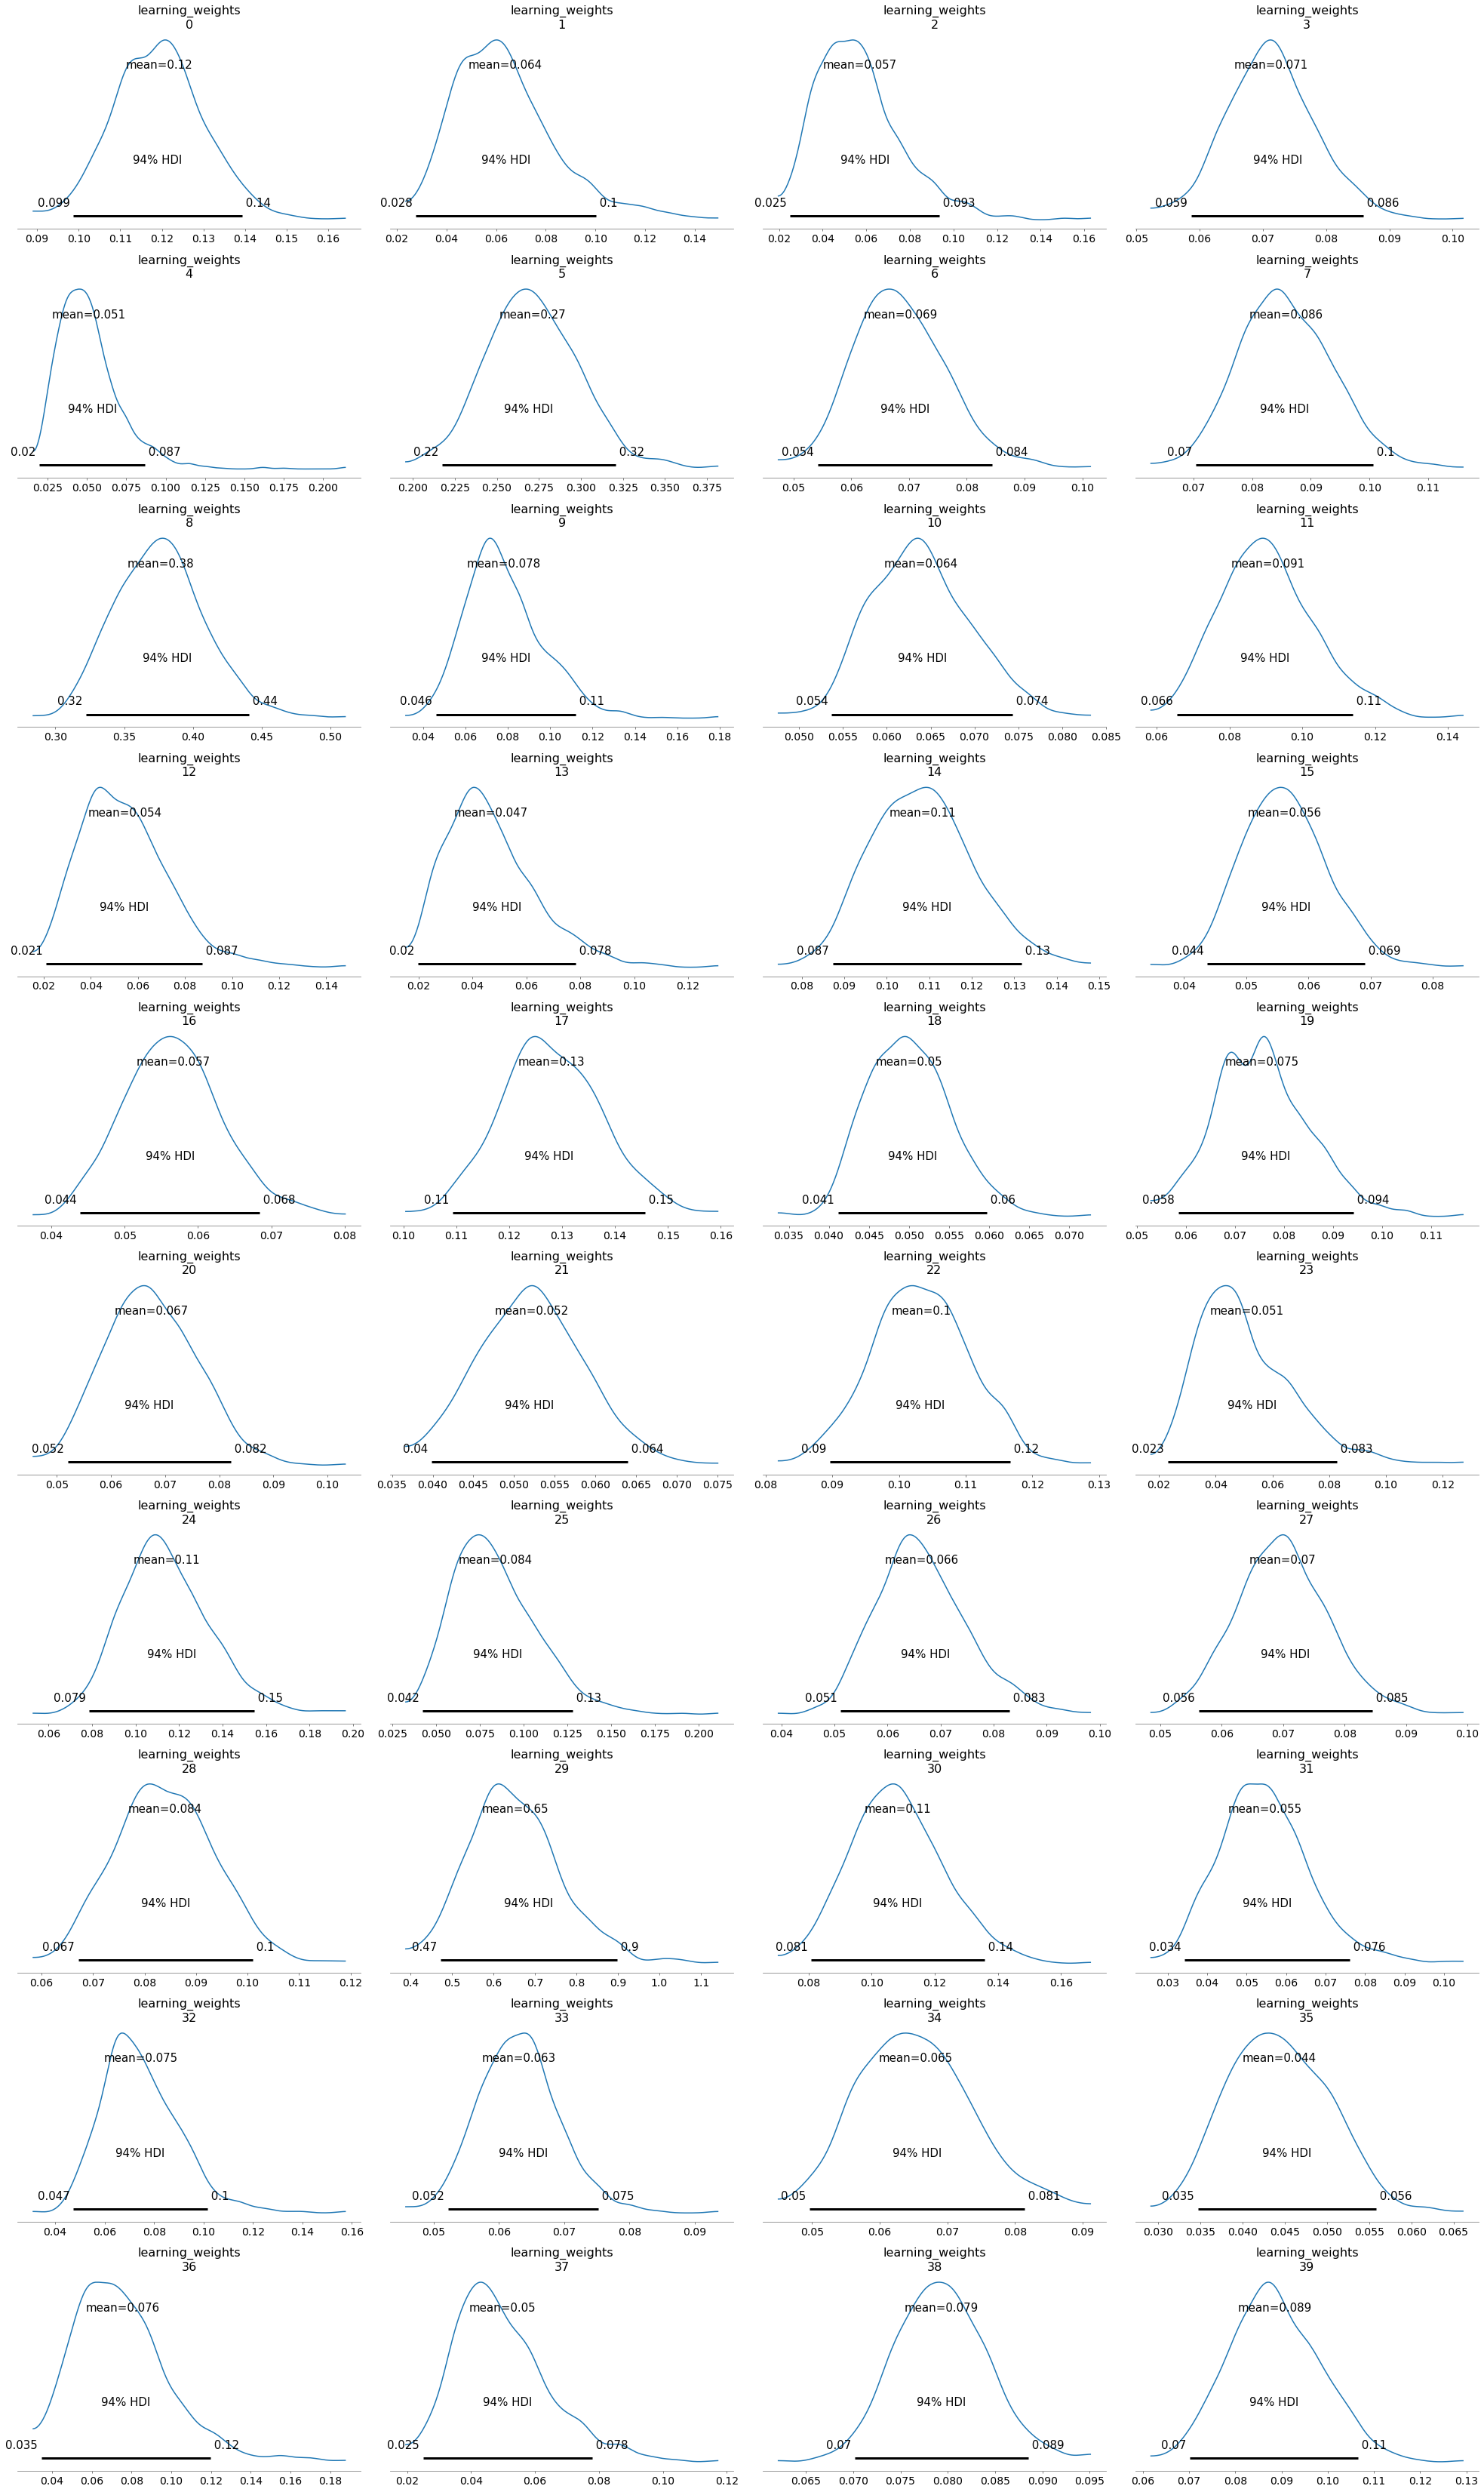

In [43]:
az.plot_posterior(
    trace,
    var_names='learning_weights'
)
plt.tight_layout()
plt.show()

array([[<AxesSubplot:ylabel='hyper_gammas\n1'>, <AxesSubplot:>,
        <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>],
       [<AxesSubplot:ylabel='hyper_gammas\n2'>, <AxesSubplot:>,
        <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>],
       [<AxesSubplot:ylabel='hyper_gammas\n3'>, <AxesSubplot:>,
        <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>],
       [<AxesSubplot:ylabel='hyper_gammas\n4'>, <AxesSubplot:>,
        <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>],
       [<AxesSubplot:xlabel='hyper_gammas\n0', ylabel='hyper_gammas\n5'>,
        <AxesSubplot:xlabel='hyper_gammas\n1'>,
        <AxesSubplot:xlabel='hyper_gammas\n2'>,
        <AxesSubplot:xlabel='hyper_gammas\n3'>,
        <AxesSubplot:xlabel='hyper_gammas\n4'>]], dtype=object)

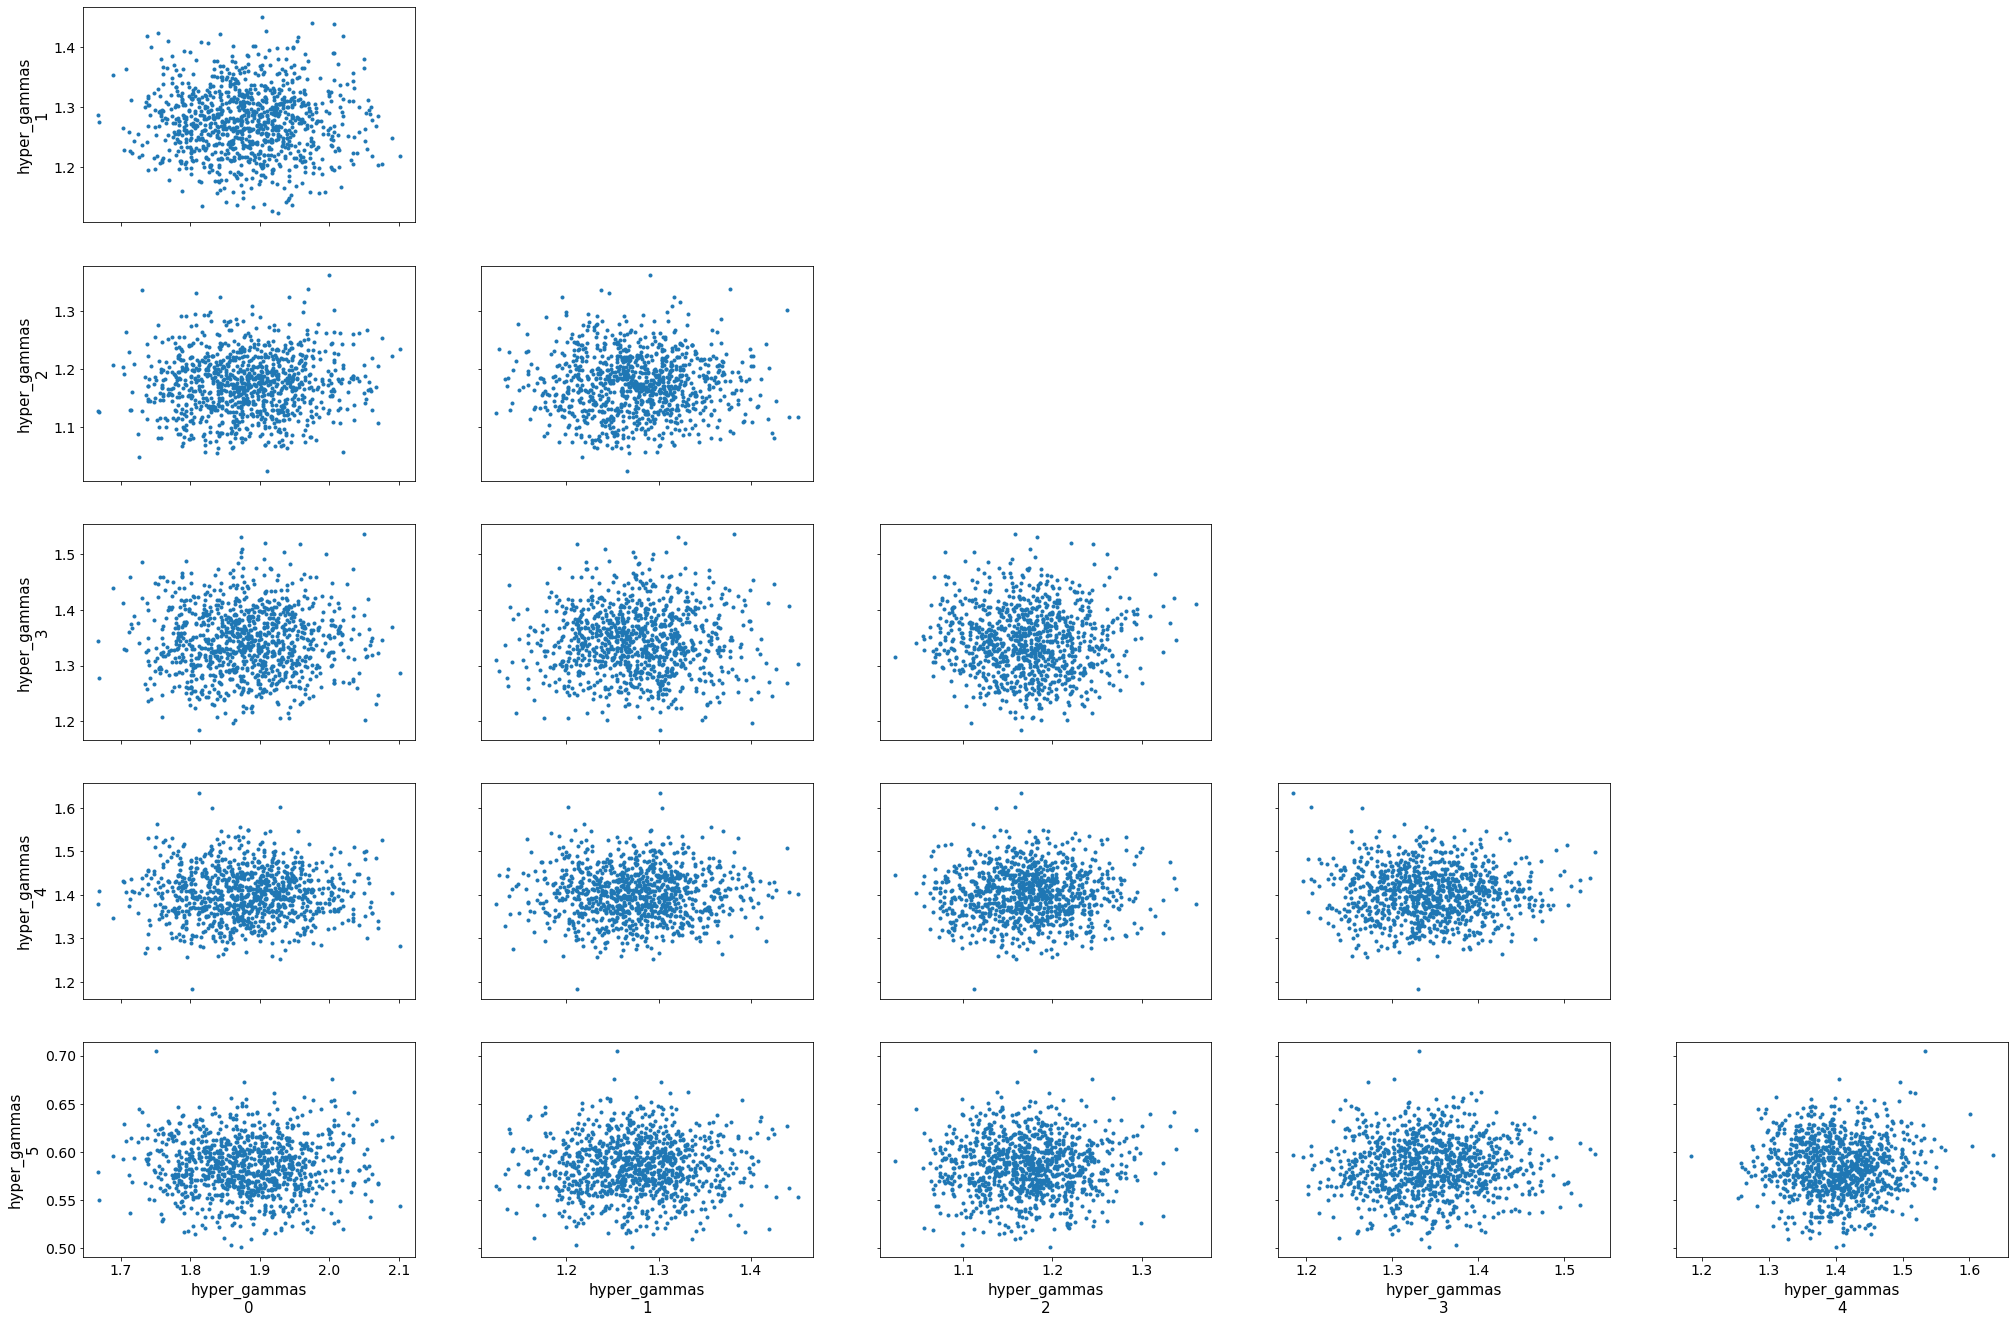

In [50]:
az.plot_pair(
    trace.posterior.hyper_gammas
)

/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/arviz/plots/traceplot.py:212: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (2715), generating only 20 plots
  warnings.warn(


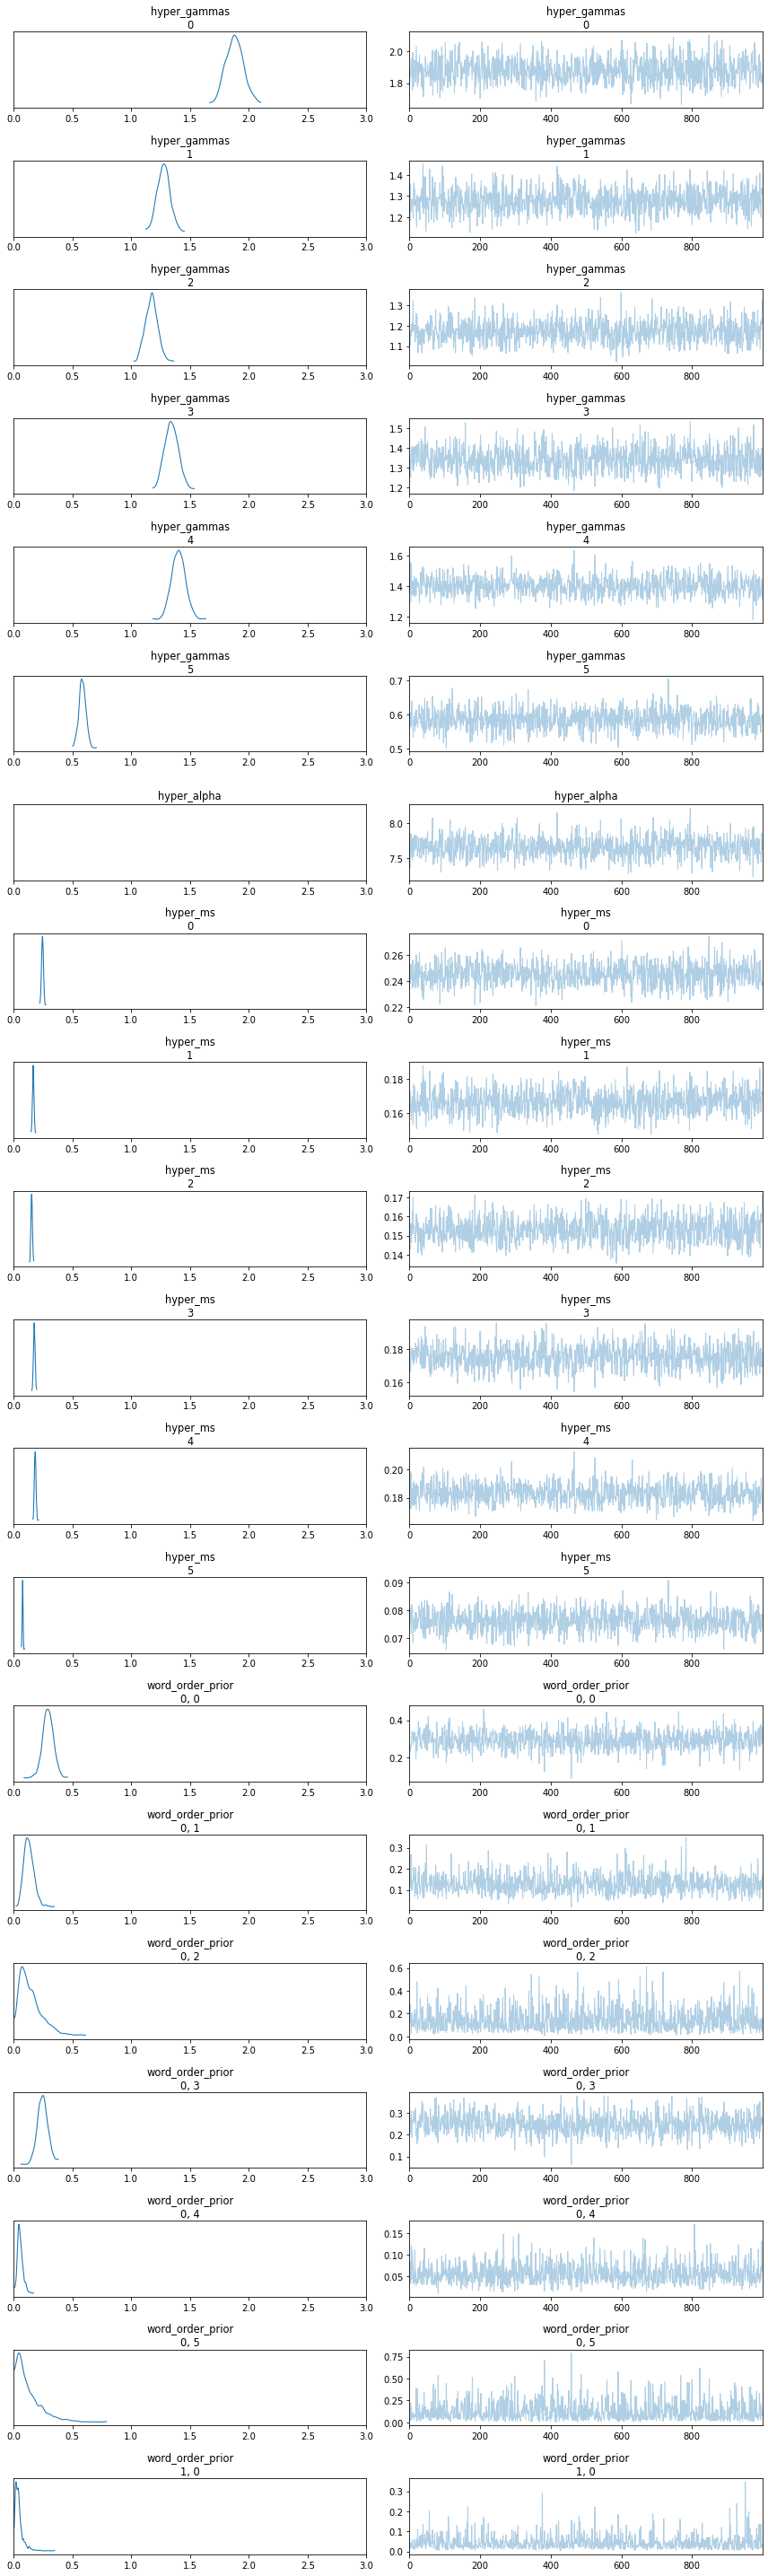

In [48]:
axes = az.plot_trace(
    trace, 
    compact=False
)
[ax.set_xlim(0, 3) for ax in axes[:,0]]
plt.tight_layout()
plt.show()

Find the posterior over ranks of preferences over word orders:

In [162]:
unique_ranks, rank_counts = np.unique(
    np.argsort(
        trace
        .posterior
        .hyper_ms
        .values
        .reshape(-1,6),
        axis=1
    ),
    return_counts=True,
    axis=0
)

wo_df = (
    pd.DataFrame(analysis_arrays['word_orders'])
    .replace({0:'s',1:'v',2:'o'})
    .apply(lambda x: '|'.join(x), axis=1)
)

order_ranks_df = pd.DataFrame(unique_ranks).replace(wo_df)
order_ranks_df.loc[:,'posterior'] = rank_counts/rank_counts.sum()
order_ranks_df.sort_values('posterior', ascending=False)

,0,1,2,3,4,5,posterior
3,o|v|s,v|s|o,s|o|v,v|o|s,o|s|v,s|v|o,0.492
4,o|v|s,v|s|o,s|o|v,o|s|v,v|o|s,s|v|o,0.194
5,o|v|s,v|s|o,v|o|s,s|o|v,o|s|v,s|v|o,0.158
0,o|v|s,s|o|v,v|s|o,v|o|s,o|s|v,s|v|o,0.067
6,o|v|s,v|s|o,v|o|s,o|s|v,s|o|v,s|v|o,0.025
1,o|v|s,s|o|v,v|s|o,o|s|v,v|o|s,s|v|o,0.024
7,o|v|s,v|s|o,o|s|v,s|o|v,v|o|s,s|v|o,0.018
8,o|v|s,v|s|o,o|s|v,v|o|s,s|o|v,s|v|o,0.011
10,o|v|s,v|o|s,v|s|o,s|o|v,o|s|v,s|v|o,0.007
2,o|v|s,s|o|v,v|o|s,v|s|o,o|s|v,s|v|o,0.002


Check if there is a pattern of learning weight values across word orders:

<AxesSubplot:xlabel='meanw', ylabel='response'>

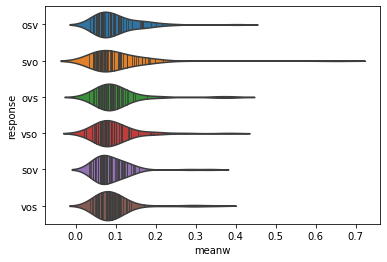

In [156]:
learningw_by_partic = analysis_arrays['word_order_partic'].copy()

learningw_by_partic.loc[:,'meanw'] = trace.posterior.learning_weights.values.mean((0,1))

sns.violinplot(
    data=learningw_by_partic,
    x='meanw',
    y='response',
    inner='stick'
)

## With participants exclusion, full dataset

In [ ]:
data, analysis_arrays, model, trace = weight_model_fit.get_and_fit_data(
    participant_exclusion=True, 
    method='hmc'
)

## With participant exclusion, first 20 trials

In [ ]:
data, analysis_arrays, model, trace = weight_model_fit.get_and_fit_data(
    participant_exclusion=True, 
    method='hmc',
    first_n_trials=20,
    fit_kwargs={'cores': 1, 'draws': 1000}
)

/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/pandas/core/indexing.py:1597: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value
/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/pandas/core/indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


Got and wrangled the data
Getting only the first 20 trials
Built the model


/mnt/c/Users/faust/Dropbox/Tubingen/joint_learning/model/scripts/weight_model_fit.py:723: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace = pm.sample(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [learning_weights, learning_weights_sigma, learning_weights_mu, word_order_prior, hyper_gammas]


# Old

## Old model-free analyses (w/o bambi)

### Fitting theory-free model 

In [313]:
with pm.Model() as model_wo_switch:
    
    # sample the correlation matrix 
    # (including variance!)
    # of joint of alphas and betas 
    # at the population level
    
    sd_dist = pm.Exponential.dist(1.)
    
    chol, corr, stds = pm.LKJCholeskyCov(
        "chol", 
        n=2, 
        eta=2, 
        sd_dist=sd_dist, 
        compute_corr=True,
        store_in_trace=True
    )
    
    # sample mean of population-level
    # joint distribution over alphas and betas
    alpha_mu = pm.Normal(
        "alpha_mu", 
        0.0, 
        2.0
    )
    
    beta_mu = pm.Normal(
        "beta_mu", 
        0.0, 
        2.0, 
    )
    
    # sample alphas and betas from 
    # the joint distribution
    # (one per participant)
    partic_params = pm.MvNormal(
        "pop_params", 
        [alpha_mu, beta_mu], 
        chol=chol,
        shape=(
            participant.max()+1,
            2
        )
    )
    
    tprint()(partic_params.shape)
        
    # predicted probability of answer
    logit_ps = (
        partic_params[participant,0] + 
        partic_params[participant,1] * 
        trial
    )
    
    pm.Bernoulli(
        'correct',
        logit_p = logit_ps,
        observed=right_answers
    )

 __str__ = [386   2]


#### Prior samples

In [314]:
with model_wo_switch:
    prior_samples_wo_switch = pm.sample_prior_predictive(
        samples=50
    )

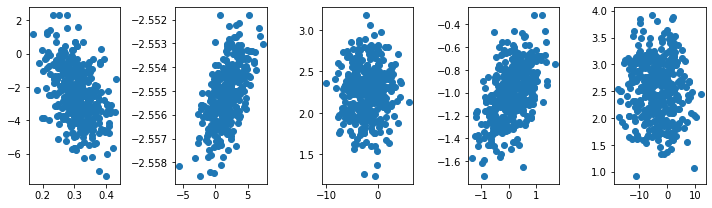

In [315]:
fig, axes = plt.subplots(1,5,figsize=(10,3))
for i, ax in enumerate(axes):
    ax.scatter(*prior_samples_wo_switch['pop_params'][i].T)
plt.tight_layout()

#### Variational

In [88]:
with model_wo_switch:
    fit_wo_switch = pm.fit()

Finished [100%]: Average Loss = 2.7389e+05


In [89]:
samples_from_fit_wo_switch = fit_wo_switch.sample(1000)

/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/arviz/plots/plot_utils.py:271: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (783) in plot_posterior, generating only 40 plots
  warnings.warn(


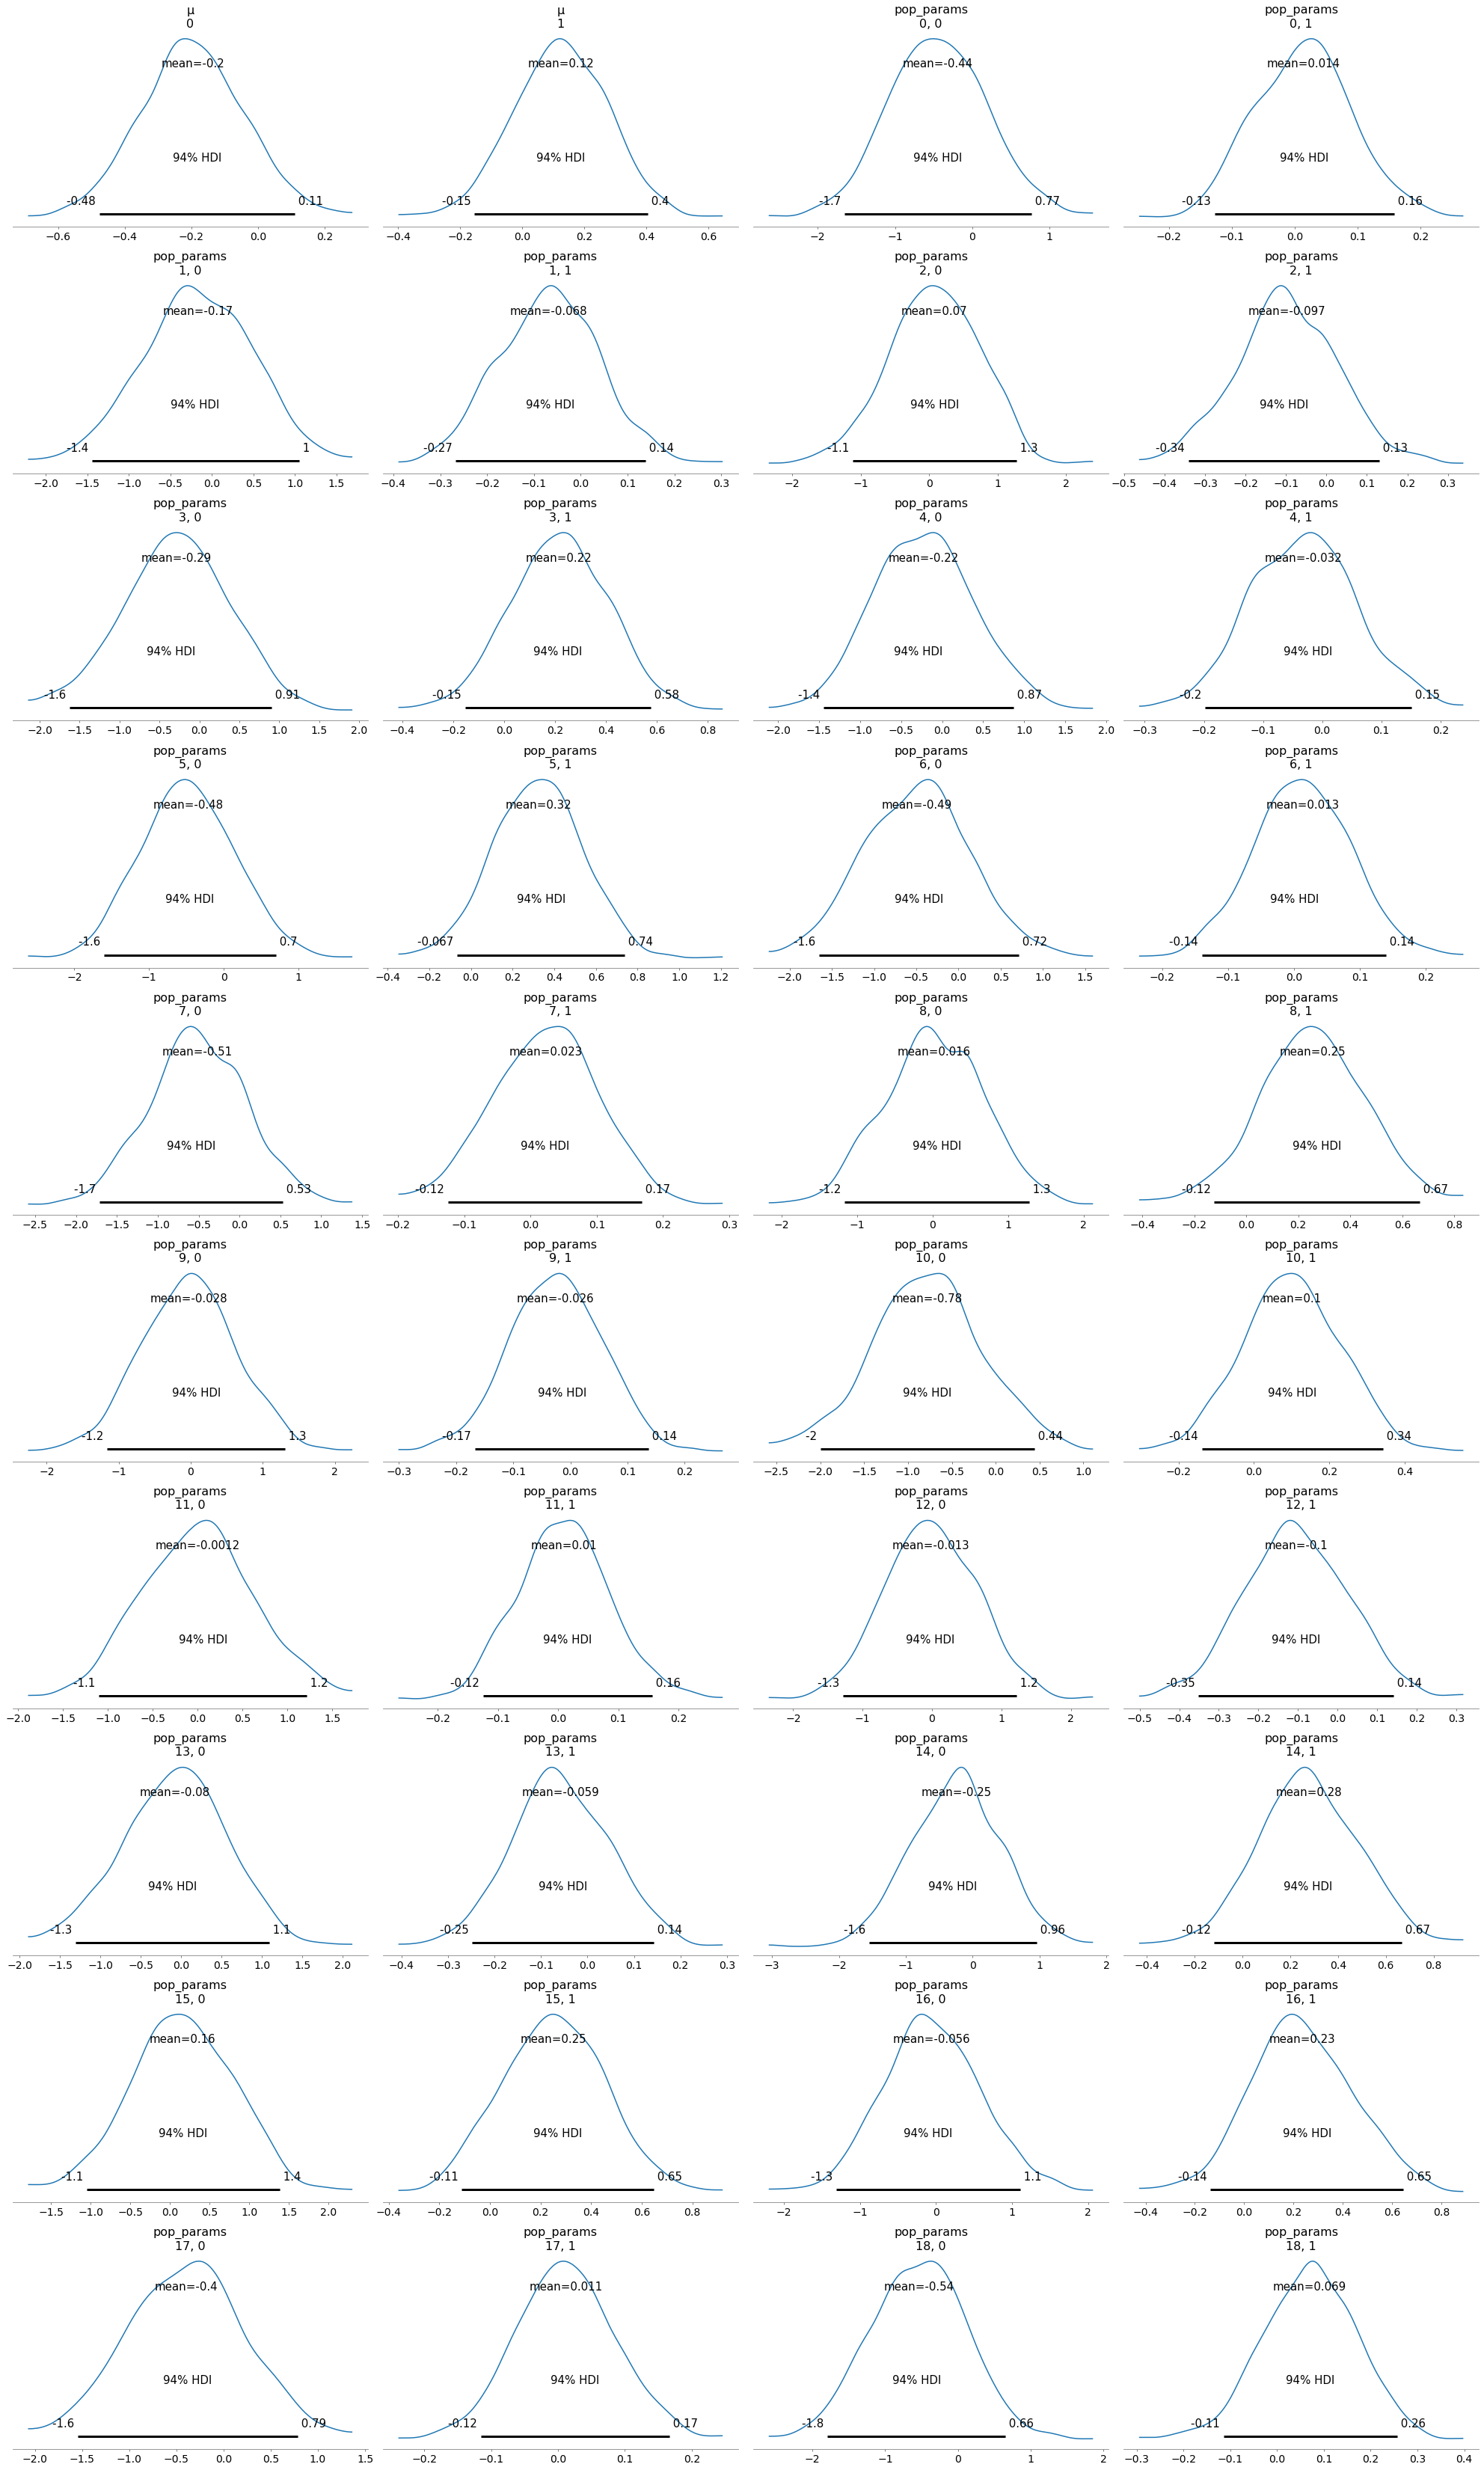

In [90]:
with model_wo_switch:
    az.plot_posterior(
        samples_from_fit_wo_switch
    )
plt.tight_layout()
plt.show()

#### MAP analysis

In [101]:
from scipy.special import expit
from pprint import pprint

In [309]:
with model_wo_switch:
    MAP_wo_switch = pm.find_MAP()

Text(0, 0.5, '$\\beta$')

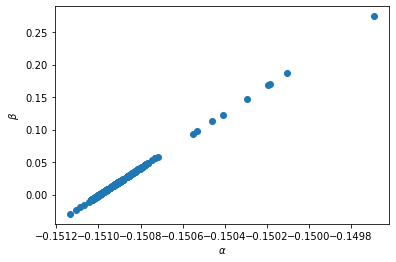

In [310]:
plt.scatter(
    *MAP_wo_switch['pop_params'].T
)
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\beta$')

In [311]:
MAP_alphas, MAP_betas = MAP_wo_switch['pop_params'].T

ps_right = expit(
    MAP_alphas[participant] + 
    MAP_betas[participant] * 
    trial
)

MAP_df = pd.DataFrame({
    'p_right': ps_right,
    'part': participant,
    'trial': trial,
    'order': word_order_partic['response'].values[participant]
})

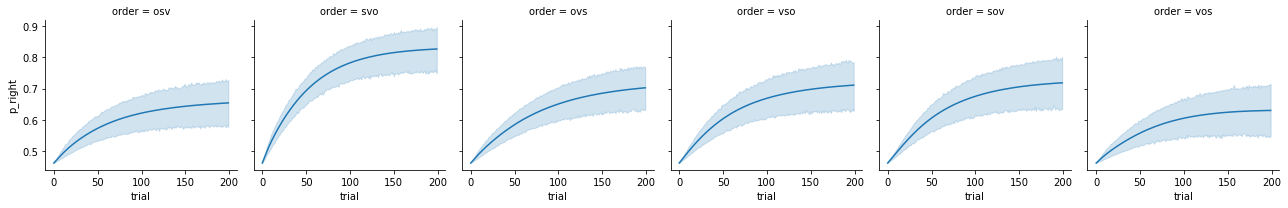

In [312]:
g = sns.FacetGrid(
    MAP_df,
    col='order',
    # hue='part'
)
    
g.map(
    sns.lineplot,
    'trial',
    'p_right'
)

#### HMC sampling (Too slow!)

In [301]:
with model_wo_switch:
    trace_wo_switch = pm.sample(
        return_inferencedata=True
    )

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pop_params, beta_mu, alpha_mu, chol]


ValueError: Not enough samples to build a trace.

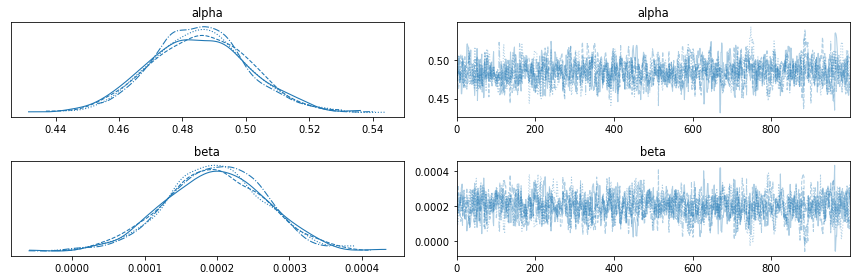

In [128]:
az.plot_trace(trace_wo_switch)
plt.tight_layout()

### Model with word order and participant structure

In [101]:
with pm.Model() as model_wo_switch:
    
    ################ Word-order-wise parameters
    
    sd_dist_wordorder = pm.Exponential.dist(0.5)
    
    chol_wordorder, _, _ = pm.LKJCholeskyCov(
        "chol_wordorder", 
        n=2, 
        eta=1.0, 
        sd_dist=sd_dist_wordorder, 
        compute_corr=True,
        store_in_trace=True
    )
    
    alpha_mu_wordorder = pm.Normal(
        "alpha_mu_wordorder", 
        0.0, 
        2.0
    )
    
    beta_mu_wordorder = pm.Normal(
        "beta_mu_wordorder", 
        0.0, 
        2.0, 
    )
    
    params_wordorder = pm.MvNormal(
        "pop_params_wordorder", 
        [alpha_mu_wordorder, beta_mu_wordorder], 
        chol=chol_wordorder,
        shape=(
            6,
            2
        )
    )
    
    ################ Participant-wise parameters
    
    sd_dist_partic = pm.Exponential.dist(0.5)
    
    # sample correlation of joint of
    # alphas and betas at the population level
    chol_partic, _, _ = pm.LKJCholeskyCov(
        "chol_partic", 
        n=2, 
        eta=1.0, 
        sd_dist=sd_dist_partic, 
        compute_corr=True,
        store_in_trace=True
    )
    
    # sample mean of population-level
    # joint distribution over alphas and betas
    alpha_mu_partic = pm.Normal(
        "alpha_mu_partic", 
        0.0, 
        2
    )
    
    beta_mu_partic = pm.Normal(
        "beta_mu_partic", 
        0.0, 
        2, 
    )
    
    # sample alphas and betas from 
    # the joint distribution
    # (one per participant)
    params_partic = pm.MvNormal(
        "pop_params_partic", 
        [alpha_mu_partic, beta_mu_partic], 
        chol=chol_partic,
        shape=(
            participant.max()+1,
            2
        )
    )
        
    ###################### LIKELIHOOD
    
    # Make predictions for each datapoint
    # that only depend on the word order
    # of the participant
    logit_ps_wordorder = (
        params_partic[participant,0] + 
        trial * params_partic[participant,1]
    )
    
    # Add the participant-dependent
    # effect
    # predicted probability of answer
    logit_ps = logit_ps_wordorder + (
        params_wordorder[wordorder,0] +
        trial * params_wordorder[wordorder,1]
    )
    
    pm.Bernoulli(
        'correct',
        logit_p = logit_ps,
        observed=right_answers
    )

#### Prior samples

In [245]:
with model_wo_switch:
    prior_samples_wo_switch = pm.sample_prior_predictive(
        samples=50
    )

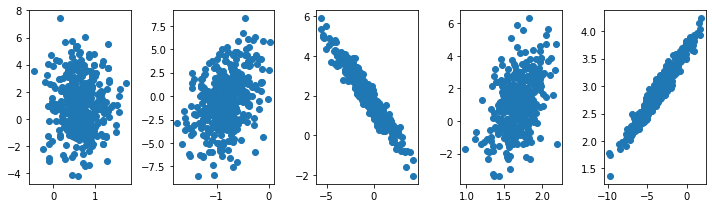

In [246]:
fig, axes = plt.subplots(1,5,figsize=(10,3))
for i, ax in enumerate(axes):
    ax.scatter(*prior_samples_wo_switch['pop_params_partic'][i].T)
plt.tight_layout()

#### MAP analysis

In [102]:
from scipy.special import expit
from pprint import pprint

In [103]:
with model_wo_switch:
    MAP_wo_switch = pm.find_MAP()

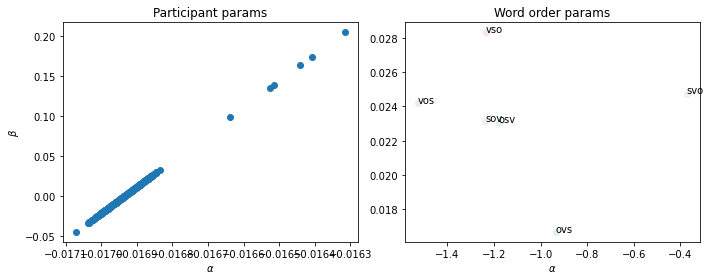

In [251]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))

ax1.scatter(
    *MAP_wo_switch['pop_params_partic'].T
)
ax1.set_xlabel(r'$\alpha$')
ax1.set_ylabel(r'$\beta$')
ax1.set_title('Participant params')

for i, txt in enumerate(wordorder_codes):
    coords = MAP_wo_switch['pop_params_wordorder'][i]
    ax2.scatter(*coords, alpha=0.1)
    ax2.annotate(
        txt,
        coords
    )
    
ax2.set_xlabel(r'$\alpha$')
ax2.set_title('Word order params')

plt.tight_layout()
plt.show()

In [233]:
MAP_pop_params_partic = MAP_wo_switch['pop_params_partic']
MAP_pop_params_wordorder = MAP_wo_switch['pop_params_wordorder']

ps_right = expit(
    MAP_pop_params_partic[participant,0] + 
    MAP_pop_params_wordorder[wordorder,0] + 
    MAP_pop_params_partic[participant,1] * trial + 
    MAP_pop_params_wordorder[wordorder,1] * trial
)

MAP_df = pd.DataFrame({
    'p_right': ps_right,
    'part': participant,
    'trial': trial,
    'order': word_order_partic['response'].values[participant]
})

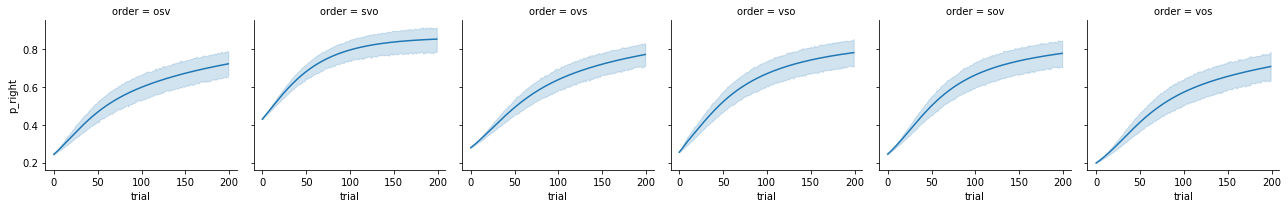

In [234]:
g = sns.FacetGrid(
    MAP_df,
    col='order',
    # hue='part'
)
    
g.map(
    sns.lineplot,
    'trial',
    'p_right'
)

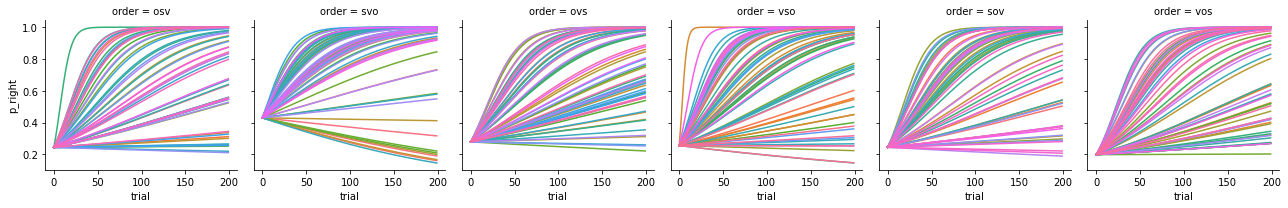

In [235]:
g = sns.FacetGrid(
    MAP_df,
    col='order',
    hue='part'
)
    
g.map(
    sns.lineplot,
    'trial',
    'p_right'
)

## Get learned language features directly from answers

A very simple model is to empirically check when people have learned the language features (word meanings + word order).

Model:
- Each participant over timesteps is encoded as a strictly increasing set of known language features.
- In particular: 
    - What each word refers to (assuming bijection between words and objects)
    - Where the verb, object, and subject is (partial knowledge is possible)
- Crucial part of the model: 
    - We know what the _true_ language is, and we know that if participants don't have the true language they'll get feedback that contradict their choices. 
    - Therefore, we can just keep track of which of the TRUE language features a participant has learned, and assume participants just sample randomly from the language until they figured out the true one.
    - In a sense, this model disregards the feedback given to participants. Just uses their choices to infer what they know at each timestep. However, it _depends_ on participants having to explore until they get to the true language, which depends on them getting feedback.
    - This model can be conceptualized as a multidimensional switchpoint model, where for each language feature, the participant goes from uniform probability (or something like that) before a certain point (the point where they figure out that language feature) to putting all probability to the true feature after a certain point (when they figure out the language).
- Crucial simplification: we don't model what _other_ language the participant is learning, just whether they have already learned the true language. The simplification is that we assume that if participants haven't yet learned the true feature, they don't believe in _another_ feature but rather just do exploration.
- Another way of looking at this is that we know what the participants will do _eventually_, namely figure out the truth, but how they do it is so complicated that we can encode it as noise. We just can't explicitly model what they mistakenly think they've learned in between.
- Having participant-wise hierarchical structure for position of switchpoint allows us to do model-comparison on how easy participants find it to infer different word orders.

Behavioural assumptions:
- At each step, the participant's knowledge state is encoded just as a Boolean vector that contains for each language feature whether the participant has learned it already
    - The boolean vector can be constructed by > comparison with the inferred switchpoints
- A knowledge state induces at each timestep a distribution over the four choices.
    - Basically, the knowledge state excludes some of the options (the ones incompatible with what the participant knows)
    - The participant chooses e.g. uniformly among the remaining ones

Free parameters:
- For each participant, the free parameters are just the positions of the switchpoint for each language feature.

Language features. Participant knows:
- Position of verb
- Position of subject
- Position of object
- Word for meaning 1
- Word for meaning 2

...

- Word for meaning 7

Note that position of verb, position of subject, and position of object are partially independent from each other. The participant might have figured out where the verb is but might be unsure which position is for subject and which for object, and viceversa. Knowing any two determines where the third is, but a participant can know just one of them. Therefore, I need to add the restriction: 
- whichever two are learned last, they are learned together. 
- This restriction means that when we're sampling the timepoints at which the positions are learned, we're effectively sampling from a 2-d surface in discrete 3-d space s.t. the two dimensions with the highest value are always equal
- There's only three ways this can happen: L(low)-H(igh)-H, HLH, HHL (position indicates verb, subject, object respectively)
- Therefore, to sample I can:
    - First, sample two numbers between 0 and max, a L(ow) and a H(igh)
    - Second, sample an order from LHH, HLH, HHL
    - Third, construct the actual numbers
- Does this way of sampling produce a reasonable prior?

The most tricky thing with this model programming-wise is how to determine efficiently whether a state and utterance are compatible given a knowledge state.

- Knowledge state is encoded by two vectors: 
    - One vector with 3 components for word order
    - One vector with 7 components for word meanings
- A sentence is encoded as an array with shape (3,3,7) and dimensions (word index, verb/subject/object, word)
- A scene is encoded as an array with shape (3,7) and dimensions (action/agent/patient, meaning)

A scene and a sentence are compatible given a language iff the language would produce the sentence for the scene. That can be calculated as:

In [ ]:
import numpy as np

In [ ]:
def likelihood_f(compatible_langs, utterance, indices_scenes):
    """
    probability of each scene given the utterance
    NOTE: mostly same as choose_scene above
    """
    # languages that produce the observed utterance for each scene
    utterance_by_language = tt.eq(compatible_langs, utterance).all(-1)
    # restrict to just available scenes
    p_lang_scene_given_utt = utterance_by_language[:,:,indices_scenes] 
    # sum over languages to get probability of 
    # each of the four scenes given the utterance
    # shape (4)
    p_scene = normalize(p_lang_scene_given_utt, axis=(0,1,2)).sum((0,1))
    return p_scene

In [ ]:
def find_compatible_langs(interpret_knowledge, order_knowledge, true_interpret, 
                          true_order, word_orders, language_interpret, languages):
    
    # indices_compatible gives the indices
    # of the interpretation function compatible with 
    # interpret_knowledge
    # Indicator functions of languages compatible with current knowledge
    # shape (interpret funcs, word orders)
    interpret_indices_compatible = (
        ~interpret_knowledge | (language_interpret==true_interpret)
    ).all(axis=1)

    # NOTE: prima facie odd way of writing this, but note that it has to work
    # when order_knowledge is all 0!
    # Conceptually: a language is excluded only if it is *known to be wrong*
    # and included if it is compatible with everything that's known
    order_indices_compatible = (~order_knowledge | (word_orders==true_order)).all(axis=1)
    
    # get just languages that are compatible with current knowledge
    # about both interpretation and order
    compatible_langs = theano.shared(languages)[interpret_indices_compatible][:,order_indices_compatible]
    
    return compatible_langs

In [ ]:
# scene
scenes, languages, language_interpret, word_orders = define_objects(4,3, full_output=True)

In [ ]:
# languages encodes the signal produced by each scene in each lang
# dims: (interpretation function, word order, scene, 3)
print('languages shape: ', languages.shape)

### Calculate probability scenes for a single trial

In [ ]:
# gives the signal for each meaning of the true language
true_interpret = language_interpret[0]
# gives the true word order
true_order = word_orders[0]

In [ ]:
# interpret_knowledge says whether the signal
# for each meaning has been figured out yet
interpret_knowledge = np.array([1, 0, 0, 1, 0, 0, 0]).astype(bool)
# order_knowledge same but for word order
order_knowledge = np.array([1,1,1]).astype(bool)

In [ ]:
compatible_langs = find_compatible_langs(
    interpret_knowledge, order_knowledge, true_interpret, 
    true_order, word_orders, language_interpret, languages
)

In [ ]:
utterance = np.array([0,1,2])
indices_scenes = np.array([0,1,2,3])
p_scenes = likelihood_f(compatible_langs, utterance, indices_scenes)

In [ ]:
# add noise!
p_scenes = normalize(p_scenes + np.random.exponential(scale=0.01))

In [ ]:
p_scenes

### Calculate probabilities for one whole participant

In [ ]:
def calculate_p_scenes(utterance, indices_scenes, noise, **kwargs):
    # Find compatible languages for each timestep
    compatible_langs = find_compatible_langs(**kwargs)
    p_scenes = likelihood_f(
        compatible_langs, 
        utterance, 
        indices_scenes
    )
    # add noise!
    p_scenes = normalize(p_scenes + noise)
    return p_scenes

In [ ]:
index_true_language = (2,3)
n_trials = 20

trials_arange = np.arange(n_trials)

# True interpretation function
true_interpret = language_interpret[index_true_language[0]]
# True word order
true_order = word_orders[index_true_language[1]]

trials = generate_trials(
    lang=languages[index_true_language], 
    n=n_trials, 
    scenes=scenes,
    n_scenes_trial=4
)

# indices_scenes_trials contains the four scenes' indices 
# seen in each trial
# (trial, 4)
# utterances_trials containg the three signals 
# observed in each trial
# (trial, 3)
_, indices_scenes_trials, utterances_trials = trials

In [ ]:
history_states, history_choices = run_experiment(
    trials, 
    interpret_prior, 
    word_order_prior, 
    negative_evidence=False
)

# go from the actual chosen scenes to their indices
history_choices_indices = np.argwhere(
    indices_scenes_trials == np.array(history_choices)[:,None]
)[:,1]

In [ ]:
with pm.Model() as model:
    
    noise = pm.Exponential(
        'noise',
        lam=6
    )
    # noise = tt.zeros(1)
    
    # interpret_discovery_timestep says for each
    # meaning at which timestep the signal for 
    # that meaning was found
    interpret_discovery_timestep = pm.DiscreteUniform(
        'index_discovered_interpret',
        lower=0, 
        upper=n_trials,
        shape=language_interpret.shape[1]
    )
    
    # interpret_discovery_timestep says for each
    # meaning at which timestep the signal for 
    # that meaning was found
    order_discovery_timestep = pm.DiscreteUniform(
        'index_discovered_order',
        lower=0, 
        upper=n_trials,
        shape=word_orders.shape[1]
    )
    
    # interpret_knowledge for each trial
    # dimensions: (trial, meaning)
    interpret_knowledge_trials = np.tile(
        trials_arange[:,None], 
        (1, language_interpret.shape[1])
    ) >= interpret_discovery_timestep
    
    # dimensions: (trial, 3)
    order_knowledge_trials = np.tile(
        trials_arange[:,None], 
        (1, word_orders.shape[1])
    ) >= order_discovery_timestep
    
    # results contains for each trial
    # the probability of the agent selecting 
    # each scene
    results,_ = theano.scan(
        fn=lambda i: calculate_p_scenes(
            theano.shared(utterances_trials)[i],
            theano.shared(indices_scenes_trials)[i],
            noise,
            # kwargs for find_compatible_langs
            interpret_knowledge = interpret_knowledge_trials[i], 
            order_knowledge = order_knowledge_trials[i], 
            true_interpret = true_interpret, 
            true_order = true_order, 
            word_orders = word_orders, 
            language_interpret = language_interpret, 
            languages = languages
        ),
        sequences=tt.arange(n_trials)
    )
    
    theano.printing.Print()(results)
    theano.printing.Print('interpret discovery')(interpret_knowledge_trials)
    theano.printing.Print('order discovery')(order_knowledge_trials)
    
    pm.Categorical('choices', p=results, observed=history_choices_indices)

In [ ]:
with model:
    samples = pm.sample(
        draws=3000, 
        return_inferencedata=True
    )

In [ ]:
az.plot_trace(samples,compact=False)
plt.tight_layout()
plt.show()